# Quick synthetic to verify that the code works as intended

In [1]:
import pygmt
import numpy as np
import matplotlib.pyplot as plt
import pyproj
import bordado as bd
import boule as bl
import harmonica as hm
import verde as vd

import spherical as sph

## Forward modeling

Test the forward modeling functions and see if they make sense.

In [2]:
region = (-60, -30, -40, -10)
grid_coordinates = bd.grid_coordinates(region, spacing=10 / 60, non_dimensional_coords=200)
dipole = (-45, -20, -250e3)
# Regional field
inclination, declination = -30, 0
dipole_moment = hm.magnetic_angles_to_vec(1e17, inclination, declination)
magnetic_field = sph.dipole_magnetic_geodetic(grid_coordinates, dipole, dipole_moment)
total_field_anomaly = vd.make_xarray_grid(
    grid_coordinates,
    hm.total_field_anomaly(magnetic_field, inclination, declination),
    data_names="grid",
    dims=("latitude", "longitude"),
    extra_coords_names="height",
).grid

Make a map with PyGMT so we can visually inspect the anomaly. It should have a positive part to the North and negative to the South.

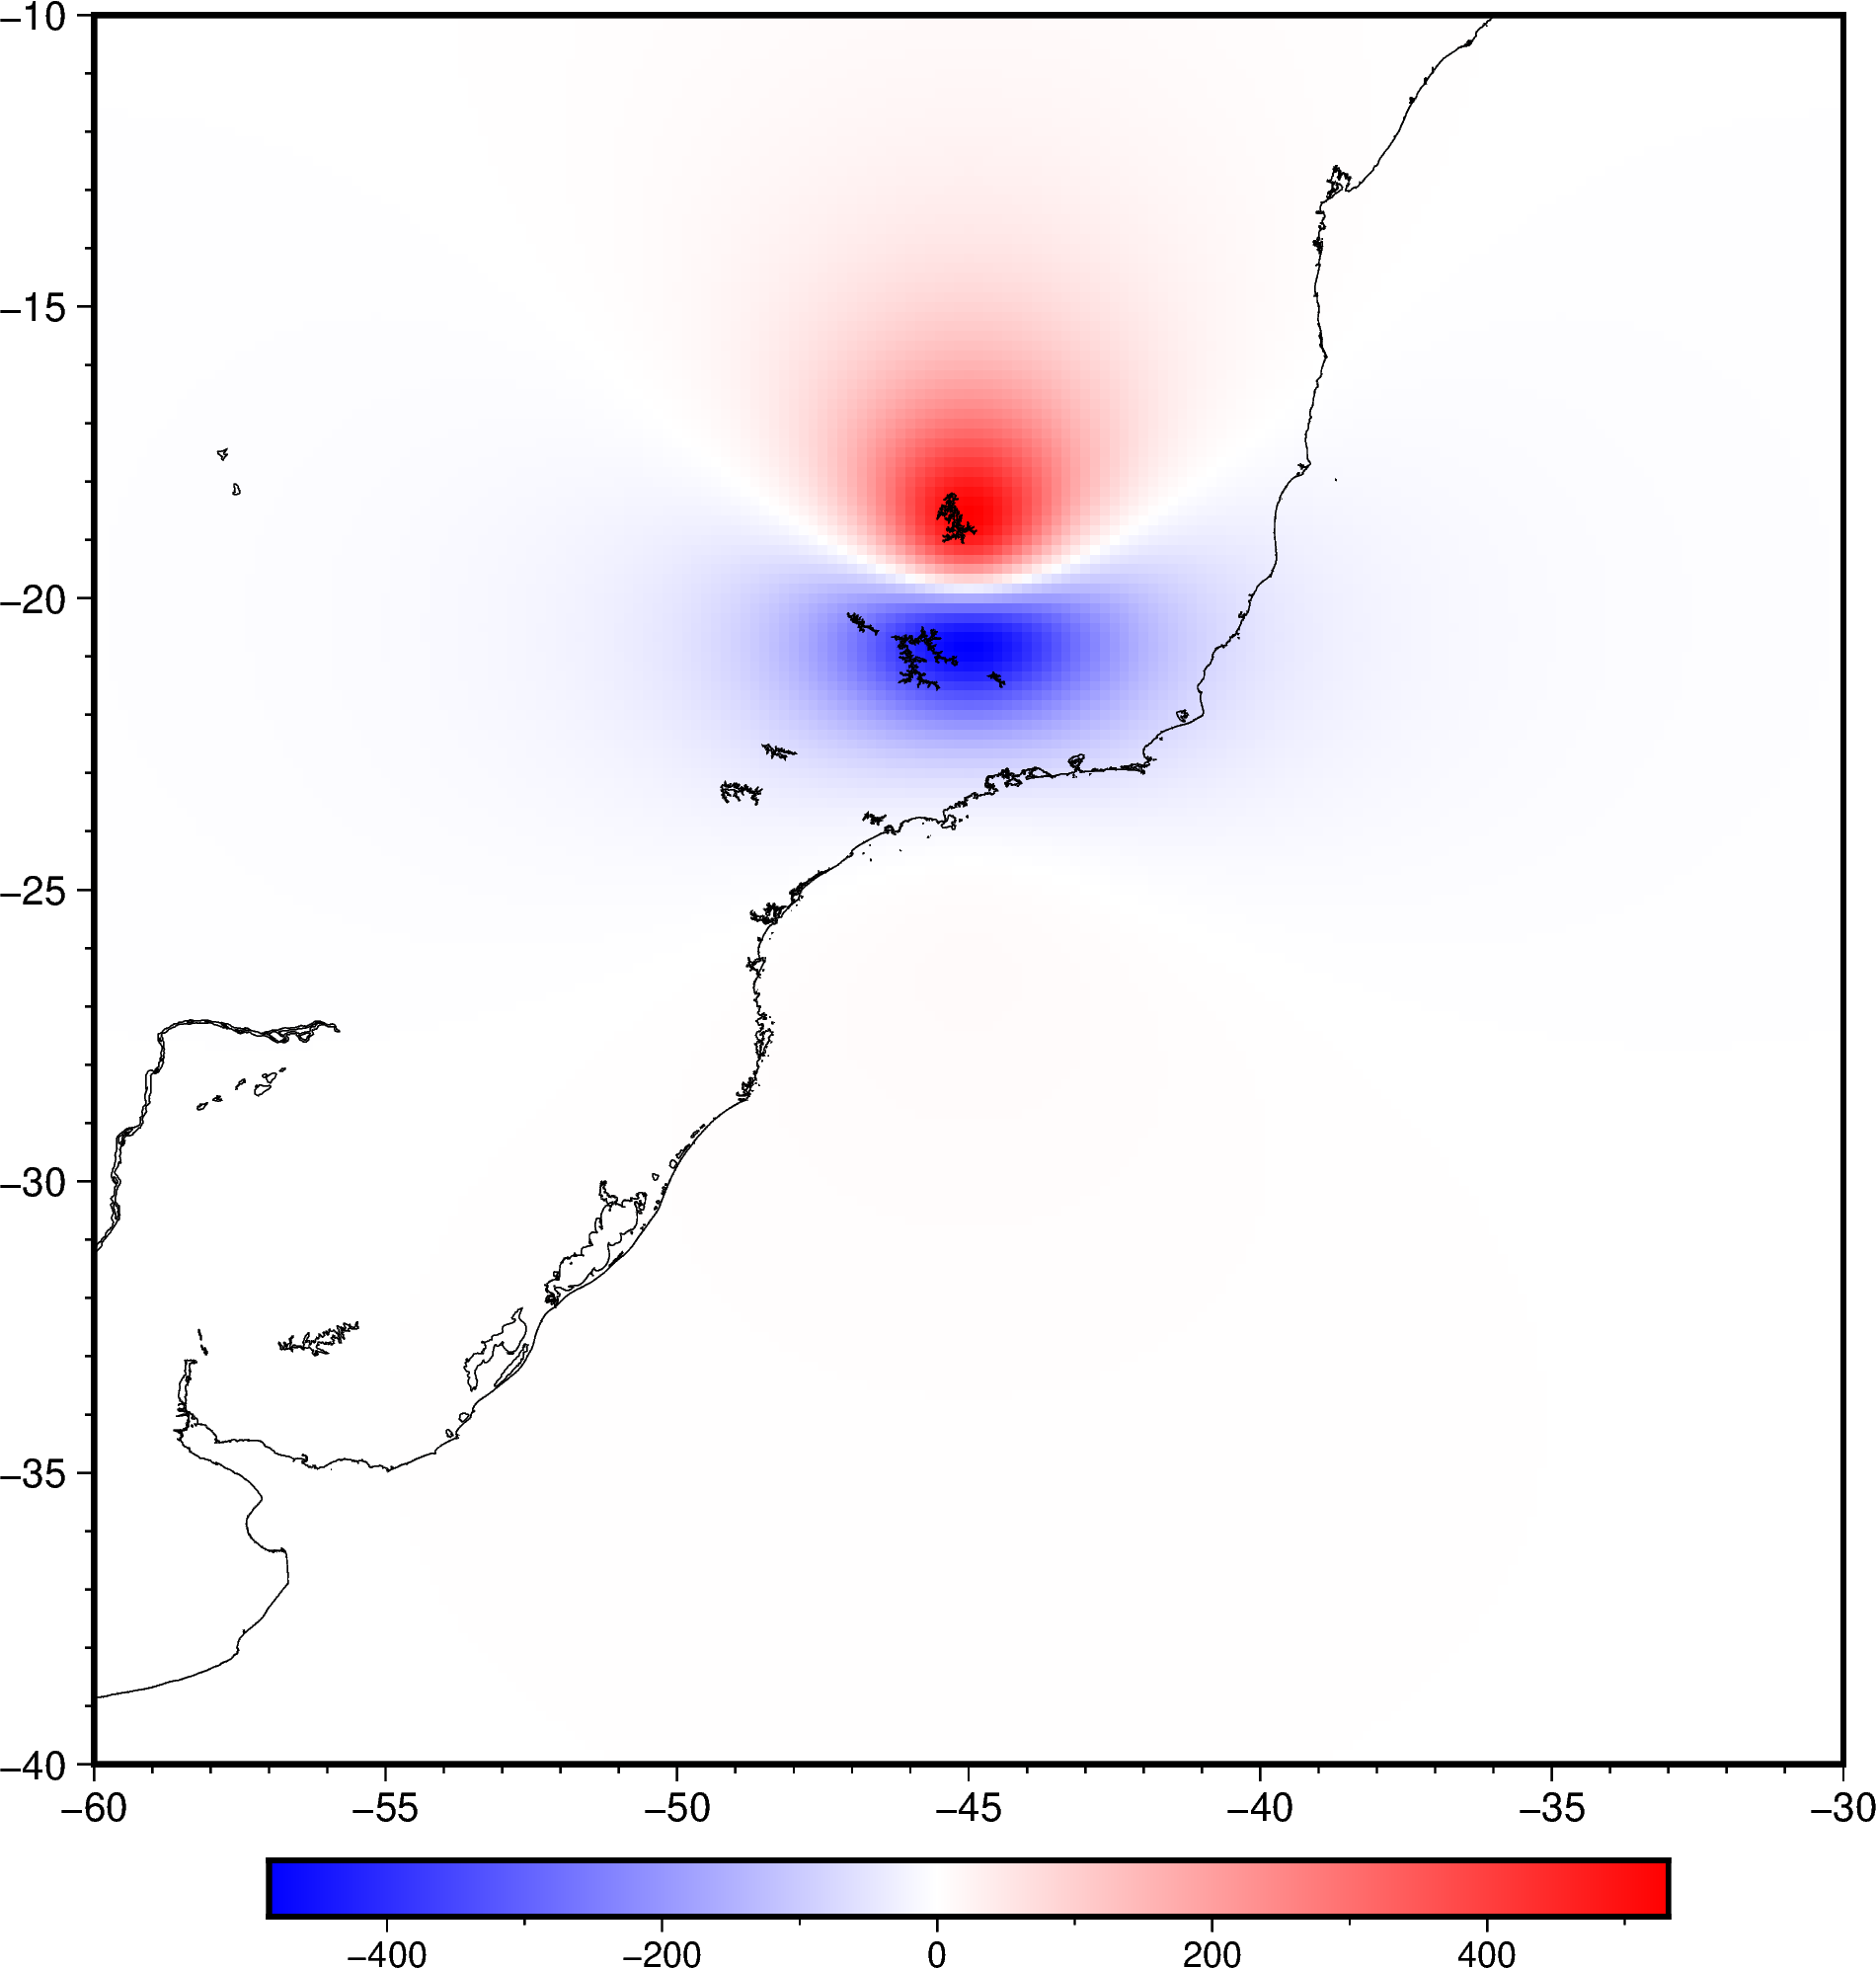

In [3]:
fig = pygmt.Figure()
fig.grdimage(total_field_anomaly, cmap="polar+h", frame=True)
fig.colorbar()
fig.coast(shorelines=True)
fig.show()

## Simple equivalent source inversion

Try recovering the dipole field with a simple single layer inversion.

In [4]:
coordinates = bd.random_coordinates(list(region) + [150, 300], 10000)
magnetic_field_obs = sph.dipole_magnetic_geodetic(coordinates, dipole, dipole_moment)
data = hm.total_field_anomaly(magnetic_field_obs, inclination, declination)
noise_level = 0.02 * vd.maxabs(data)
data += np.random.default_rng(42).normal(0, noise_level, data.shape)
print(noise_level, "nT")

10.595002893530662 nT


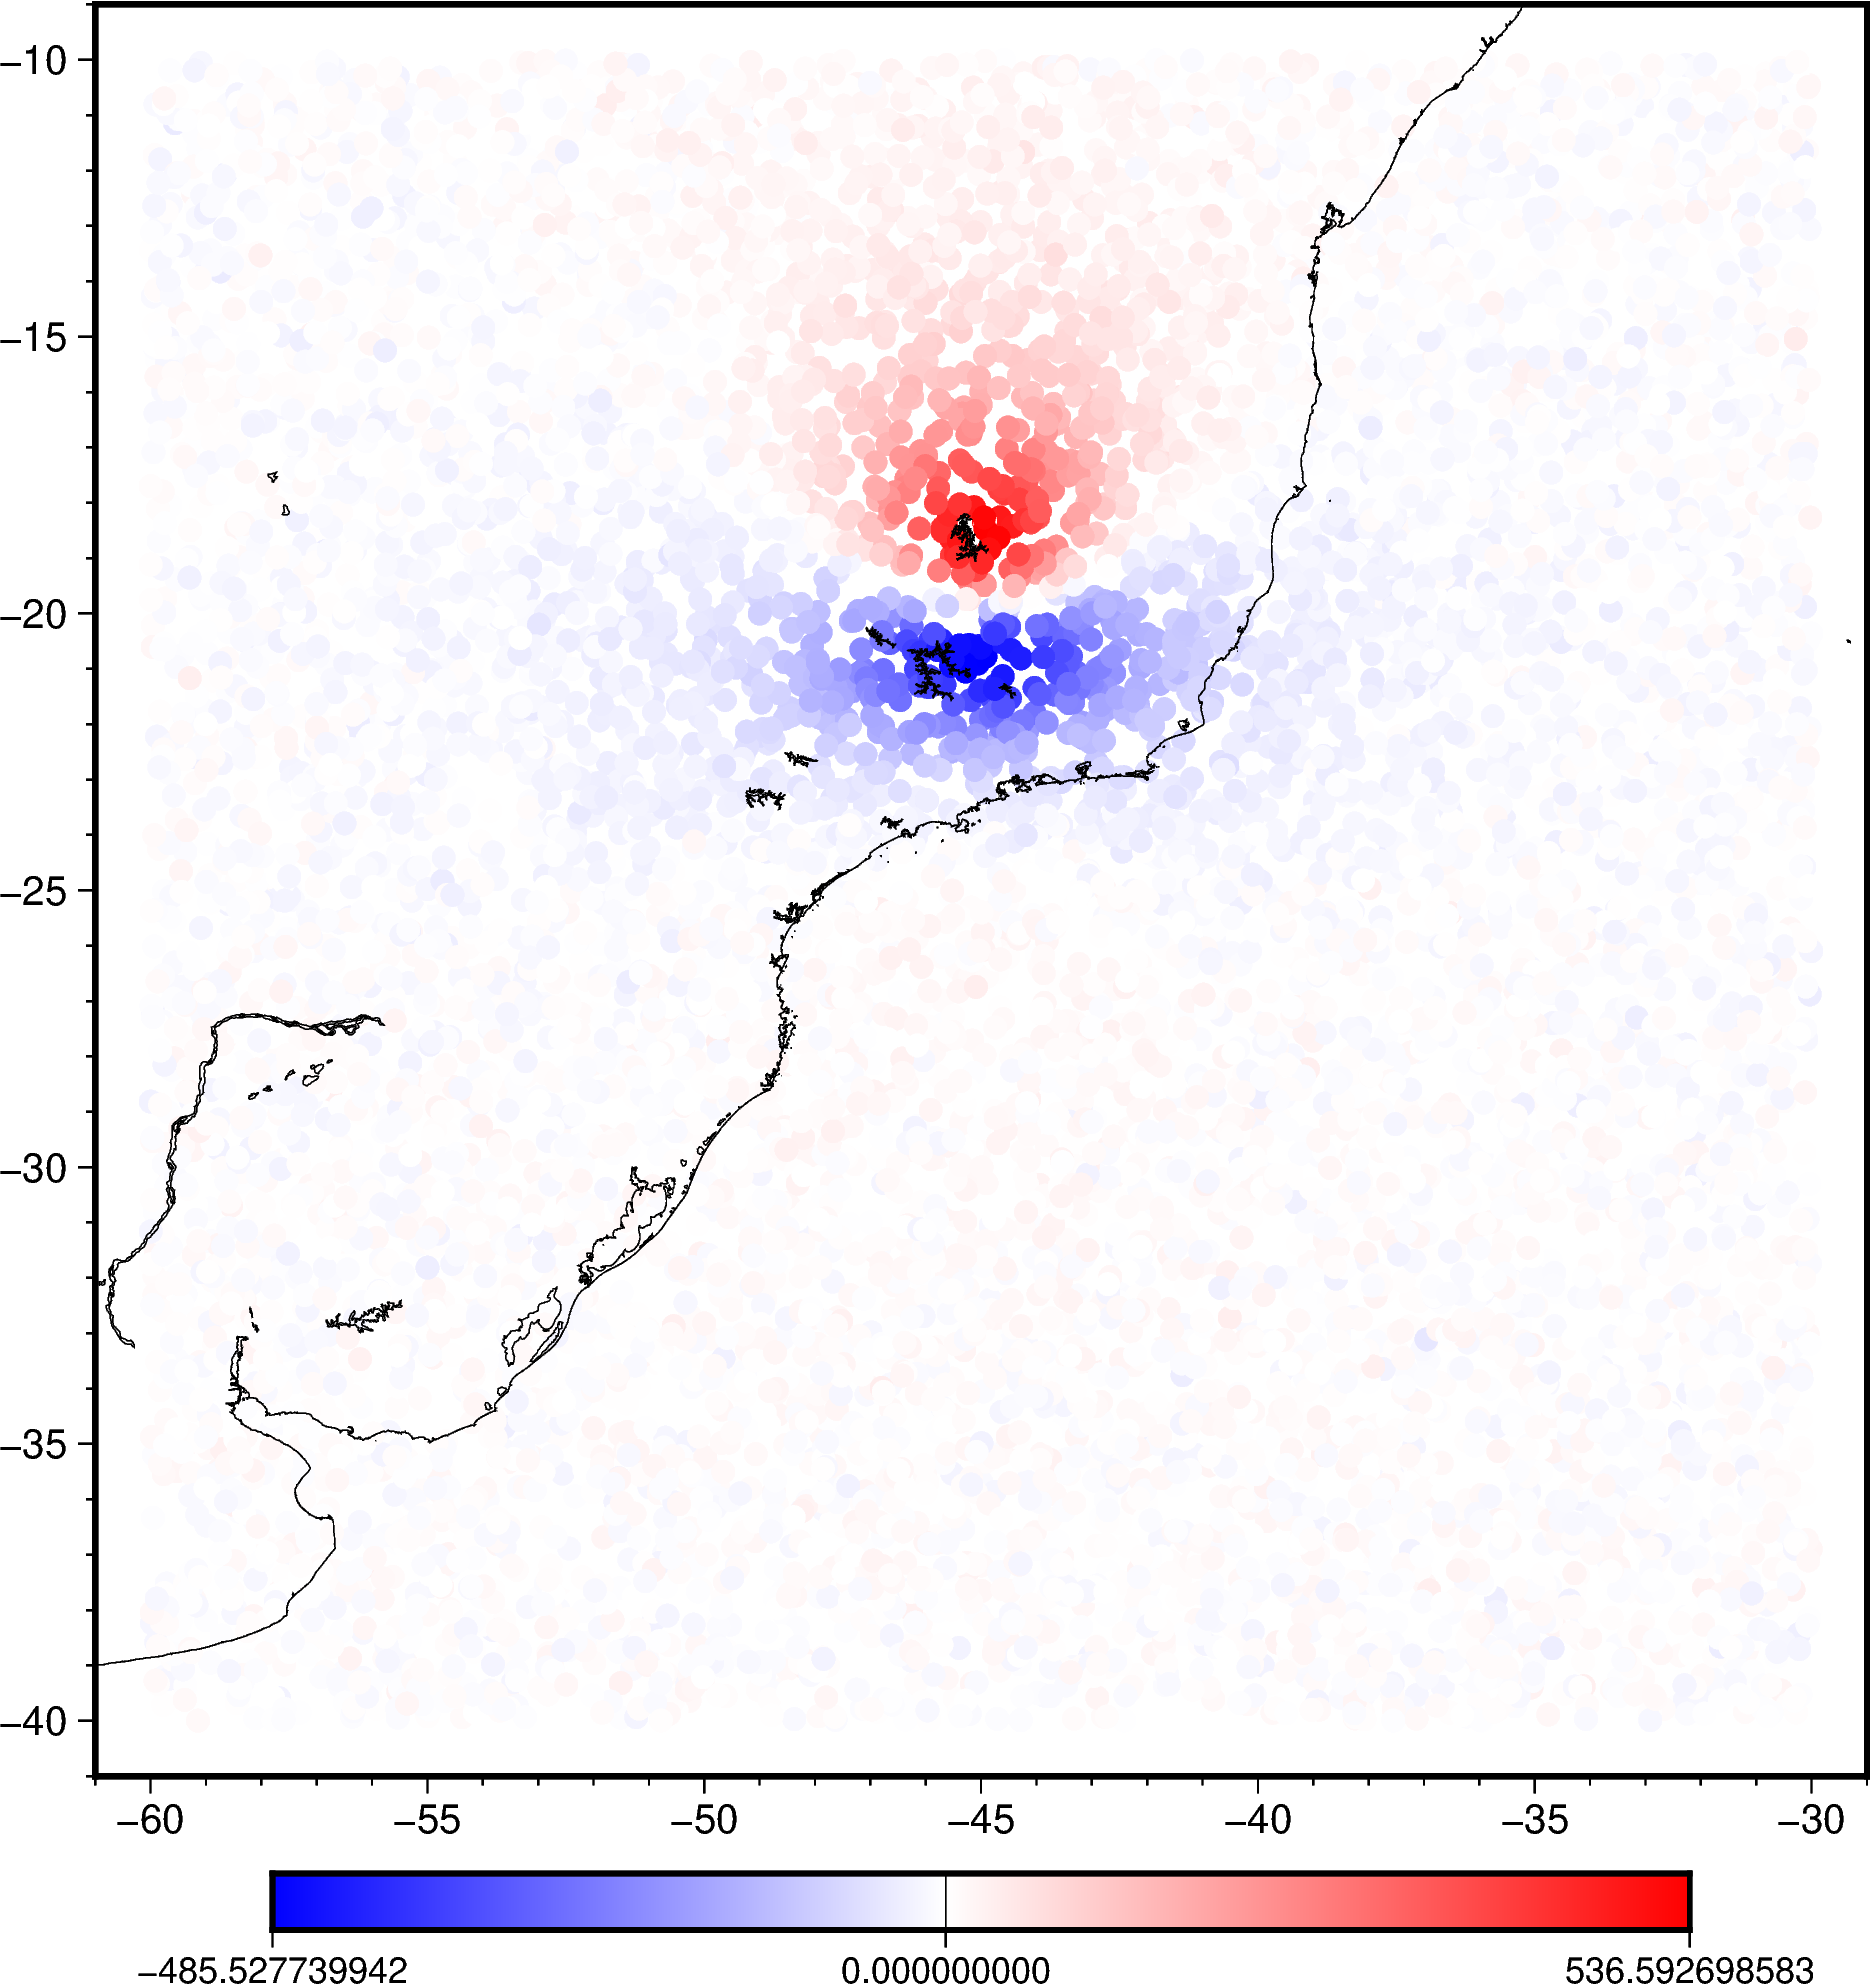

In [5]:
fig = pygmt.Figure()
pygmt.makecpt(cmap="polar+h", series=[data.min(), data.max()])
fig.plot(x=coordinates[0], y=coordinates[1], fill=data, style="c0.2c", cmap=True, frame=True)
fig.colorbar()
fig.coast(shorelines=True)
fig.show()

Run the inversion.

In [6]:
%%time
eqs = sph.EquivalentSourcesMagGeod(damping=1e1, depth=100e3)
eqs.fit(coordinates, inclination, declination, data)

CPU times: user 2min 47s, sys: 4.9 s, total: 2min 52s
Wall time: 29 s


Calculate and plot the residuals.

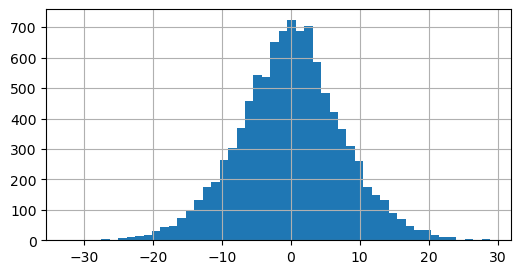

In [7]:
residuals = data - hm.total_field_anomaly(eqs.predict(coordinates), inclination, declination)
plt.figure(figsize=(6, 3))
plt.hist(residuals, bins=50)
plt.grid()
plt.show()

In [8]:
total_field_anomaly_predicted = vd.make_xarray_grid(
    grid_coordinates,
    hm.total_field_anomaly(eqs.predict(grid_coordinates), inclination, declination),
    data_names="grid",
    dims=("latitude", "longitude"),
    extra_coords_names="height",
).grid

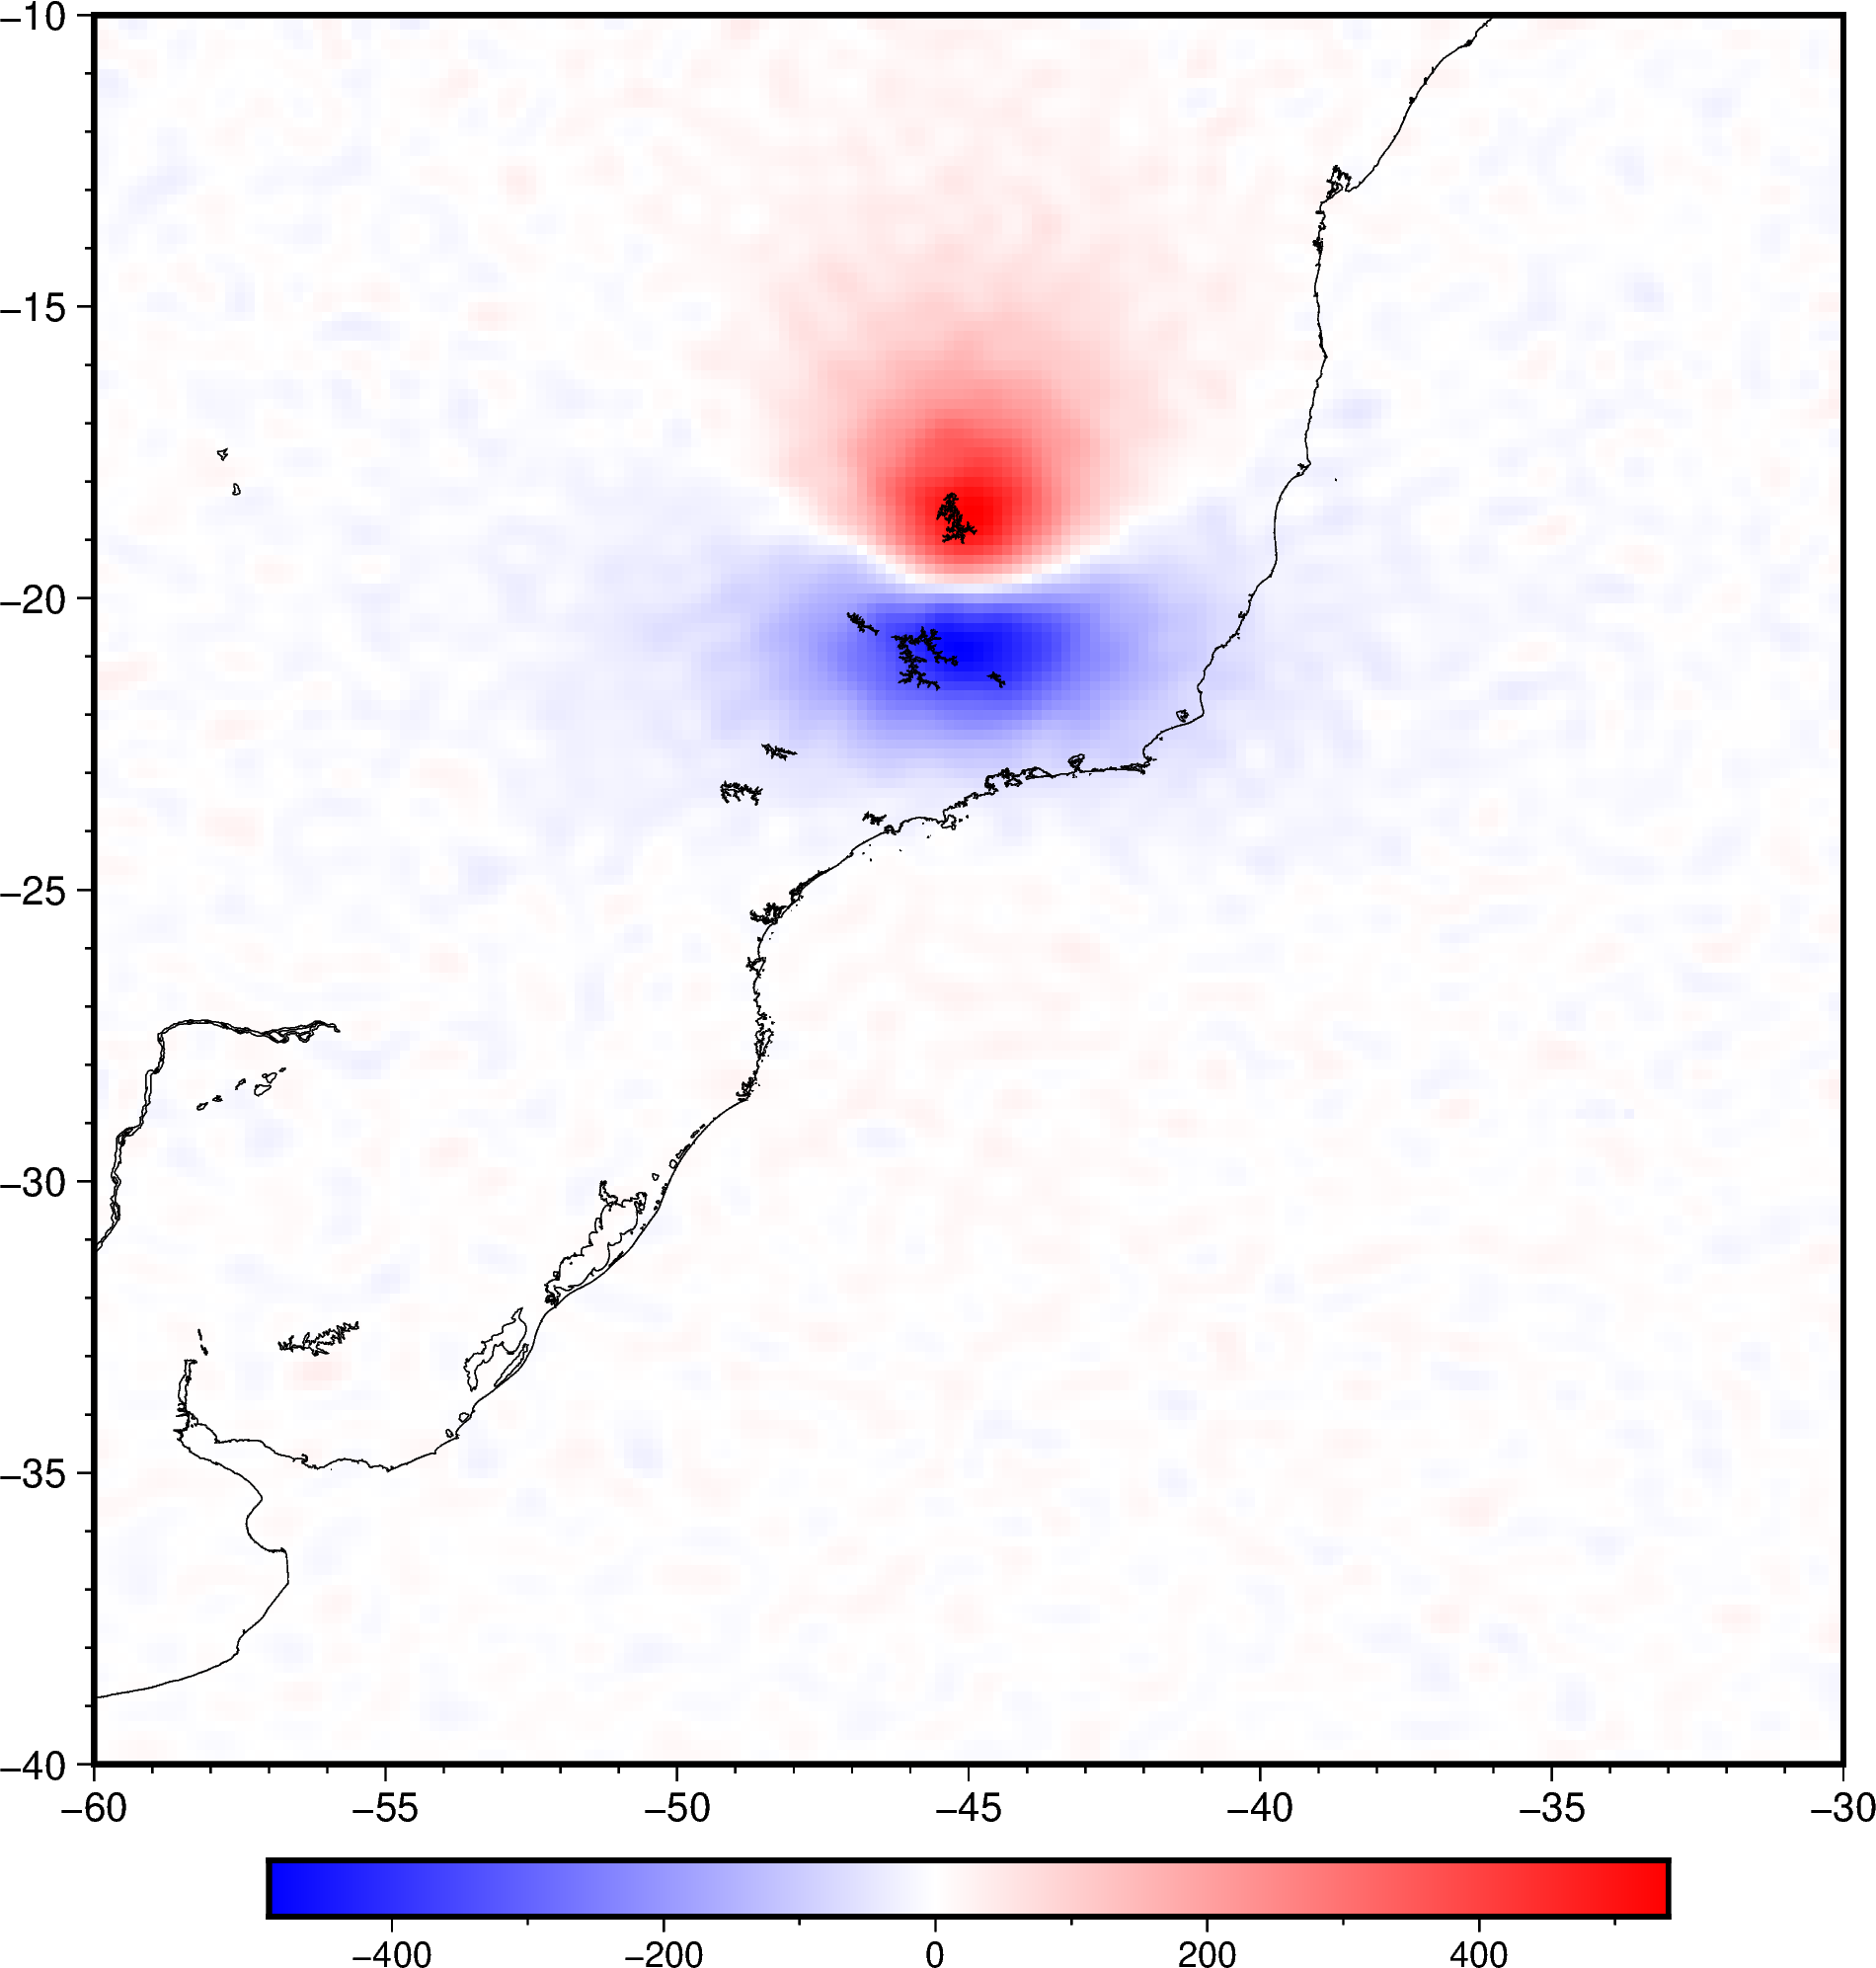

In [9]:
fig = pygmt.Figure()
fig.grdimage(total_field_anomaly_predicted, cmap="polar+h", frame=True)
fig.colorbar()
fig.coast(shorelines=True)
fig.show()

Show the difference.

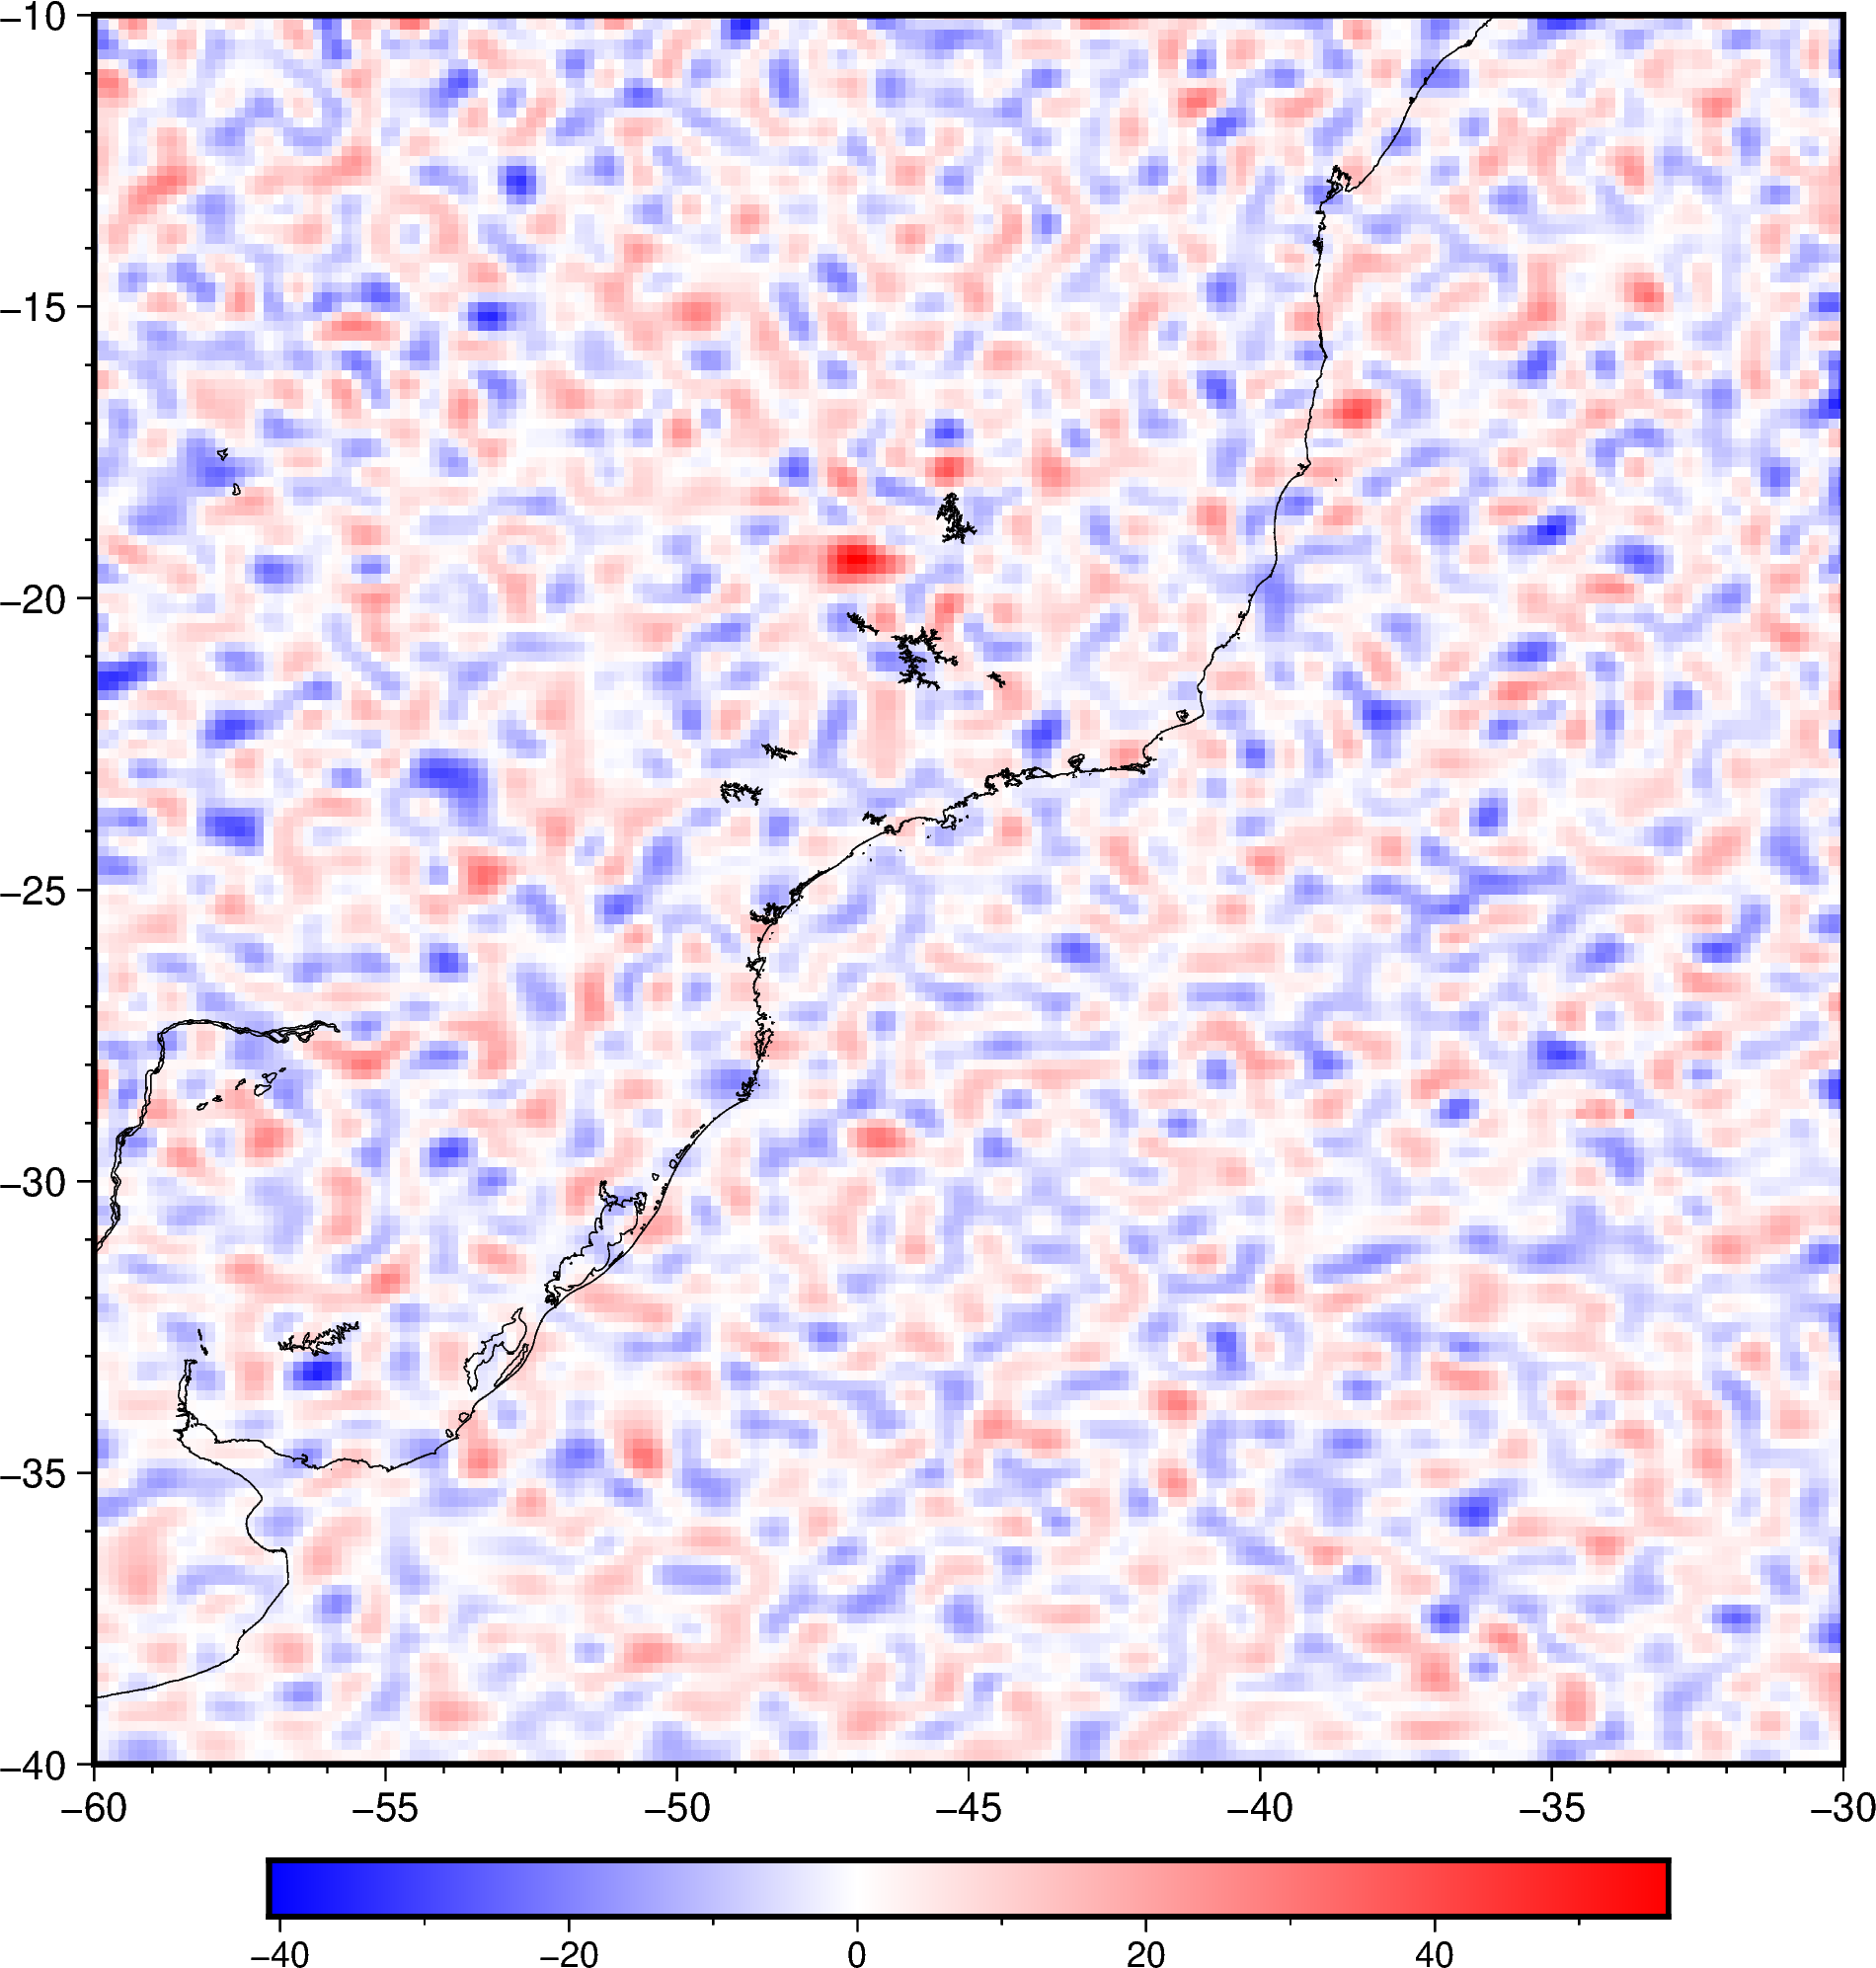

In [10]:
fig = pygmt.Figure()
fig.grdimage(total_field_anomaly - total_field_anomaly_predicted, cmap="polar+h", frame=True)
fig.colorbar()
fig.coast(shorelines=True)
fig.show()

## Gradient-boosting

In [11]:
%%time
eqs = sph.EquivalentSourcesMagGeodGB(damping=1e1, depth=100e3, window_size=1000e3)
eqs.fit(coordinates, inclination, declination, data)
print(eqs.window_size_)

Output()

1000000.0
CPU times: user 1min 21s, sys: 314 ms, total: 1min 21s
Wall time: 13.9 s


Calculate and plot the residuals.

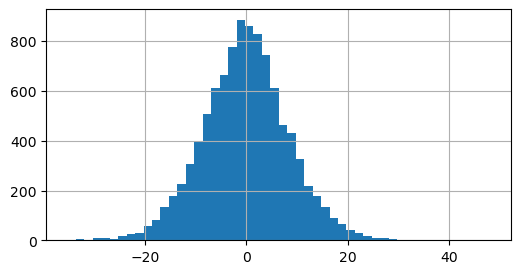

In [12]:
residuals = data - hm.total_field_anomaly(eqs.predict(coordinates), inclination, declination)
plt.figure(figsize=(6, 3))
plt.hist(residuals, bins=50)
plt.grid()
plt.show()

Predict on a grid.

In [13]:
total_field_anomaly_predicted = vd.make_xarray_grid(
    grid_coordinates,
    hm.total_field_anomaly(eqs.predict(grid_coordinates), inclination, declination),
    data_names="grid",
    dims=("latitude", "longitude"),
    extra_coords_names="height",
).grid

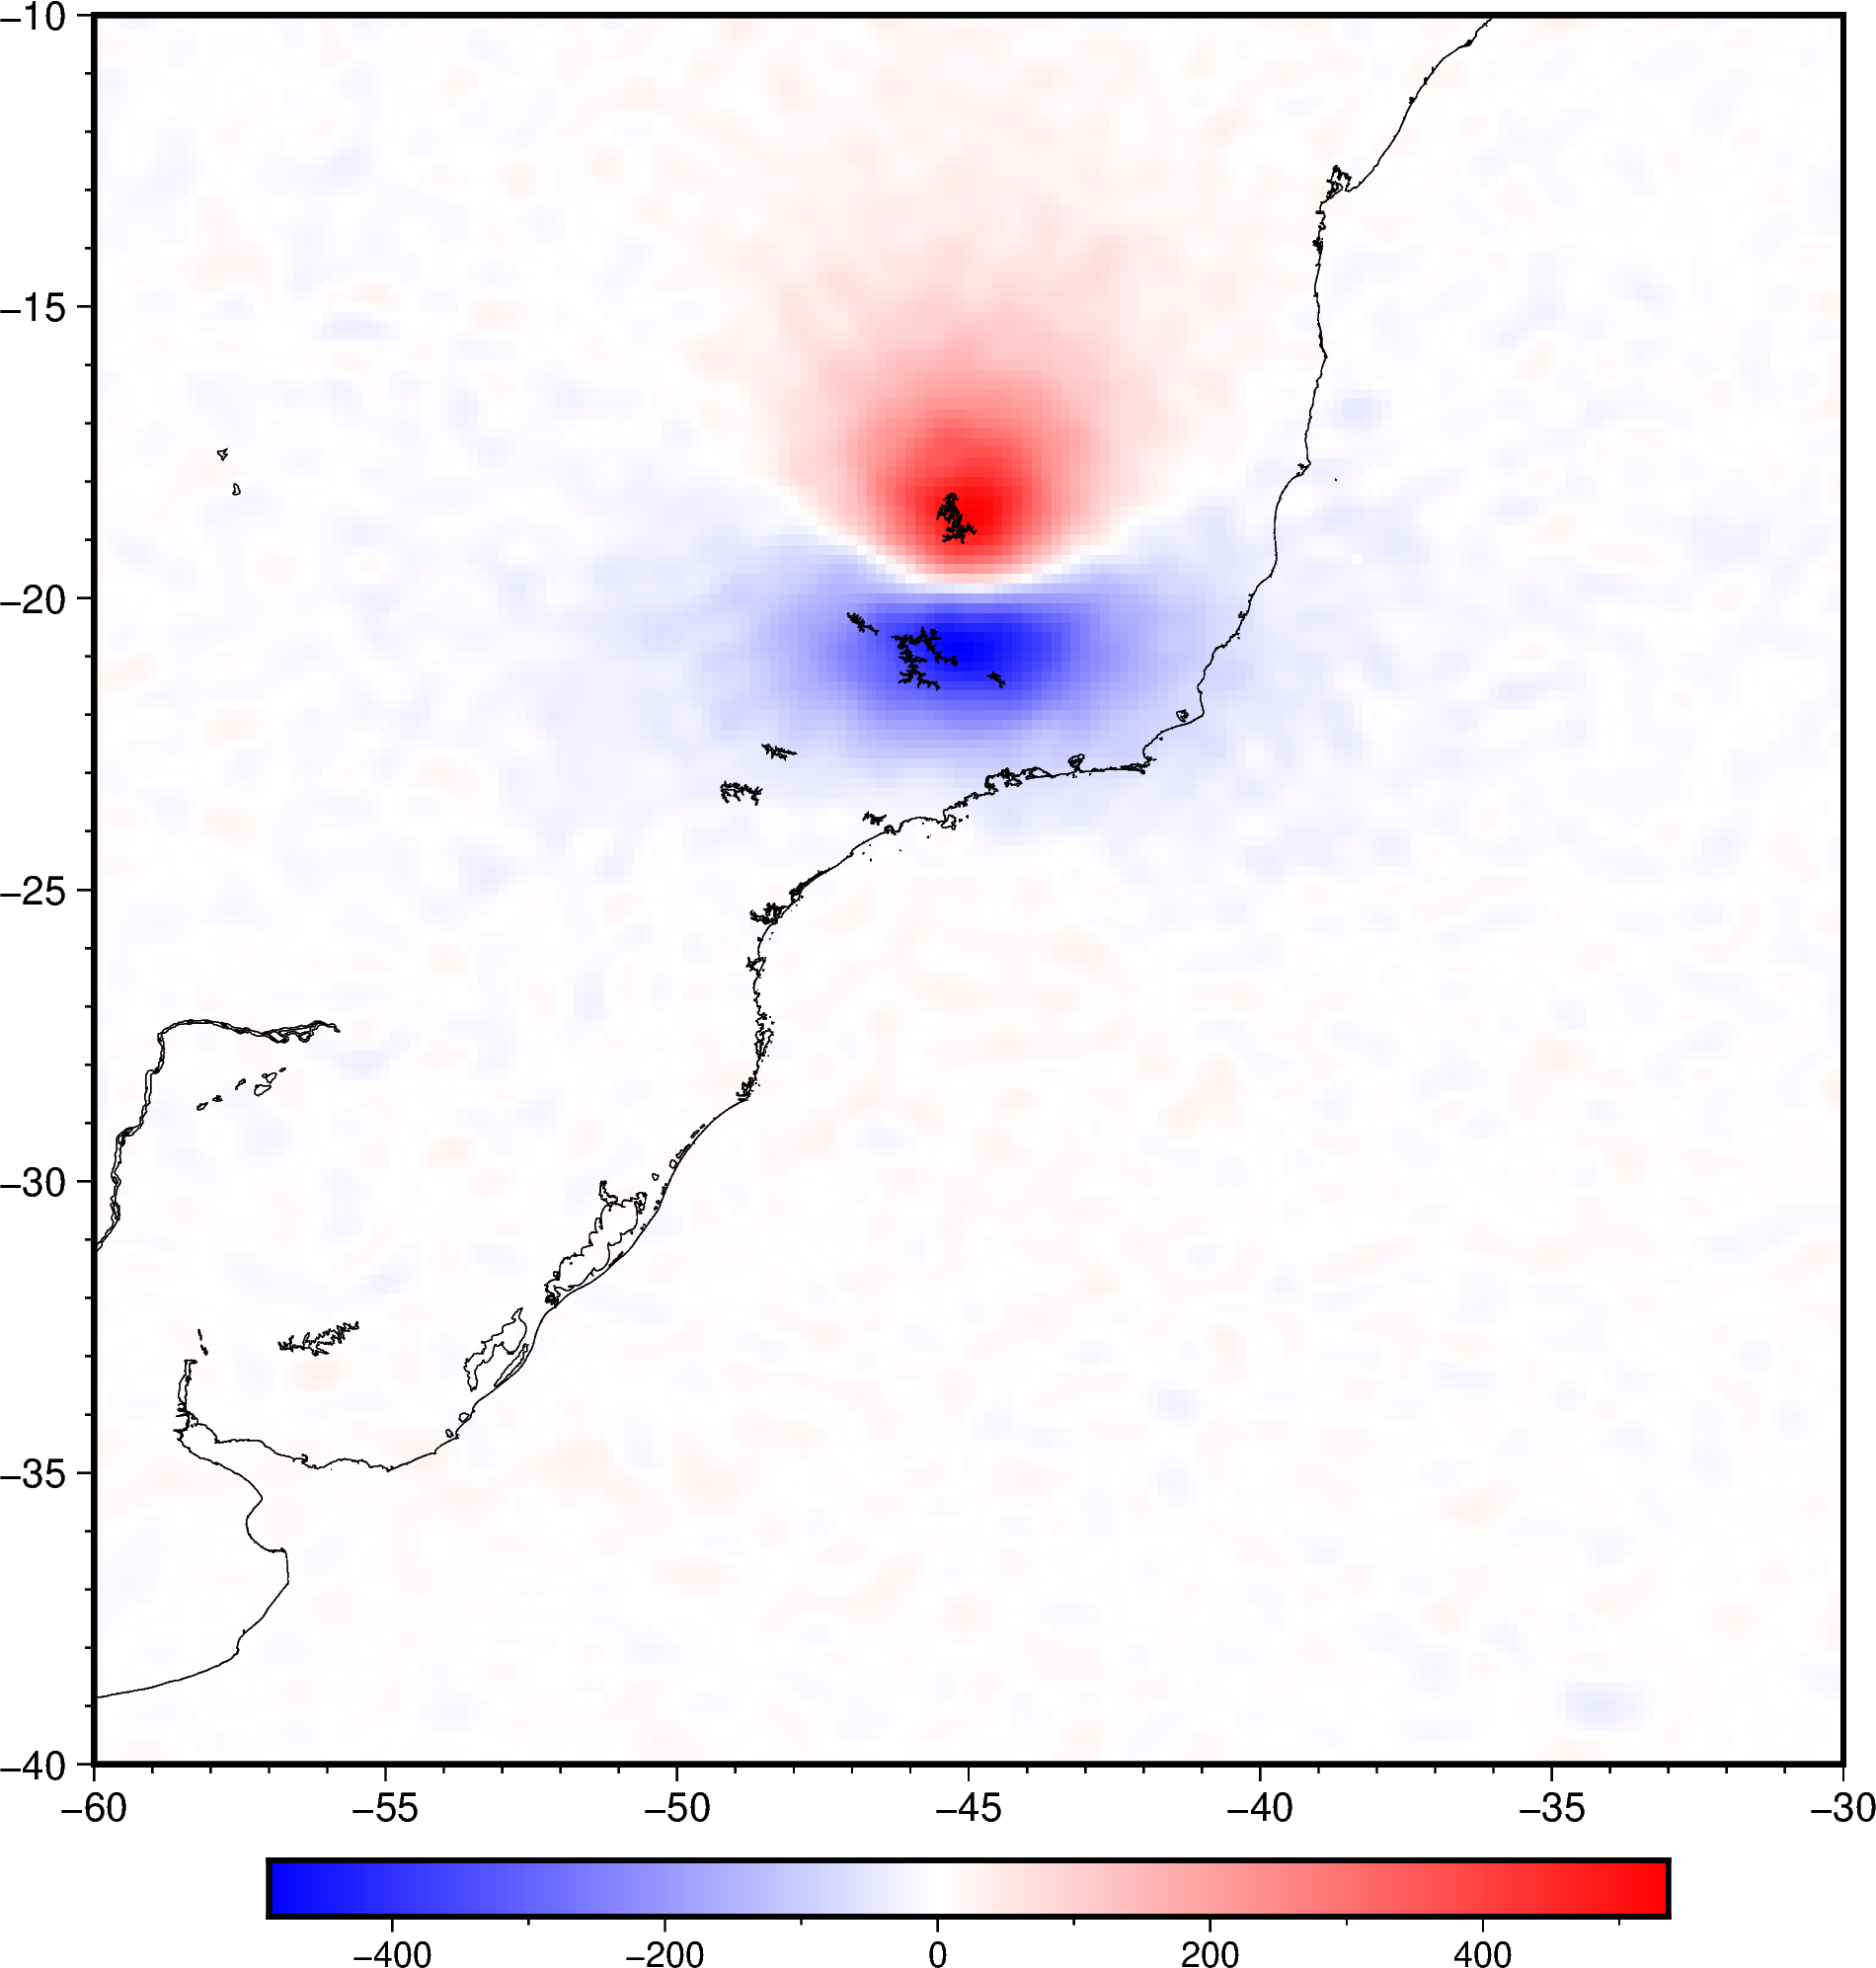

In [14]:
fig = pygmt.Figure()
fig.grdimage(total_field_anomaly_predicted, cmap="polar+h", frame=True)
fig.colorbar()
fig.coast(shorelines=True)
fig.show()

Show the difference.

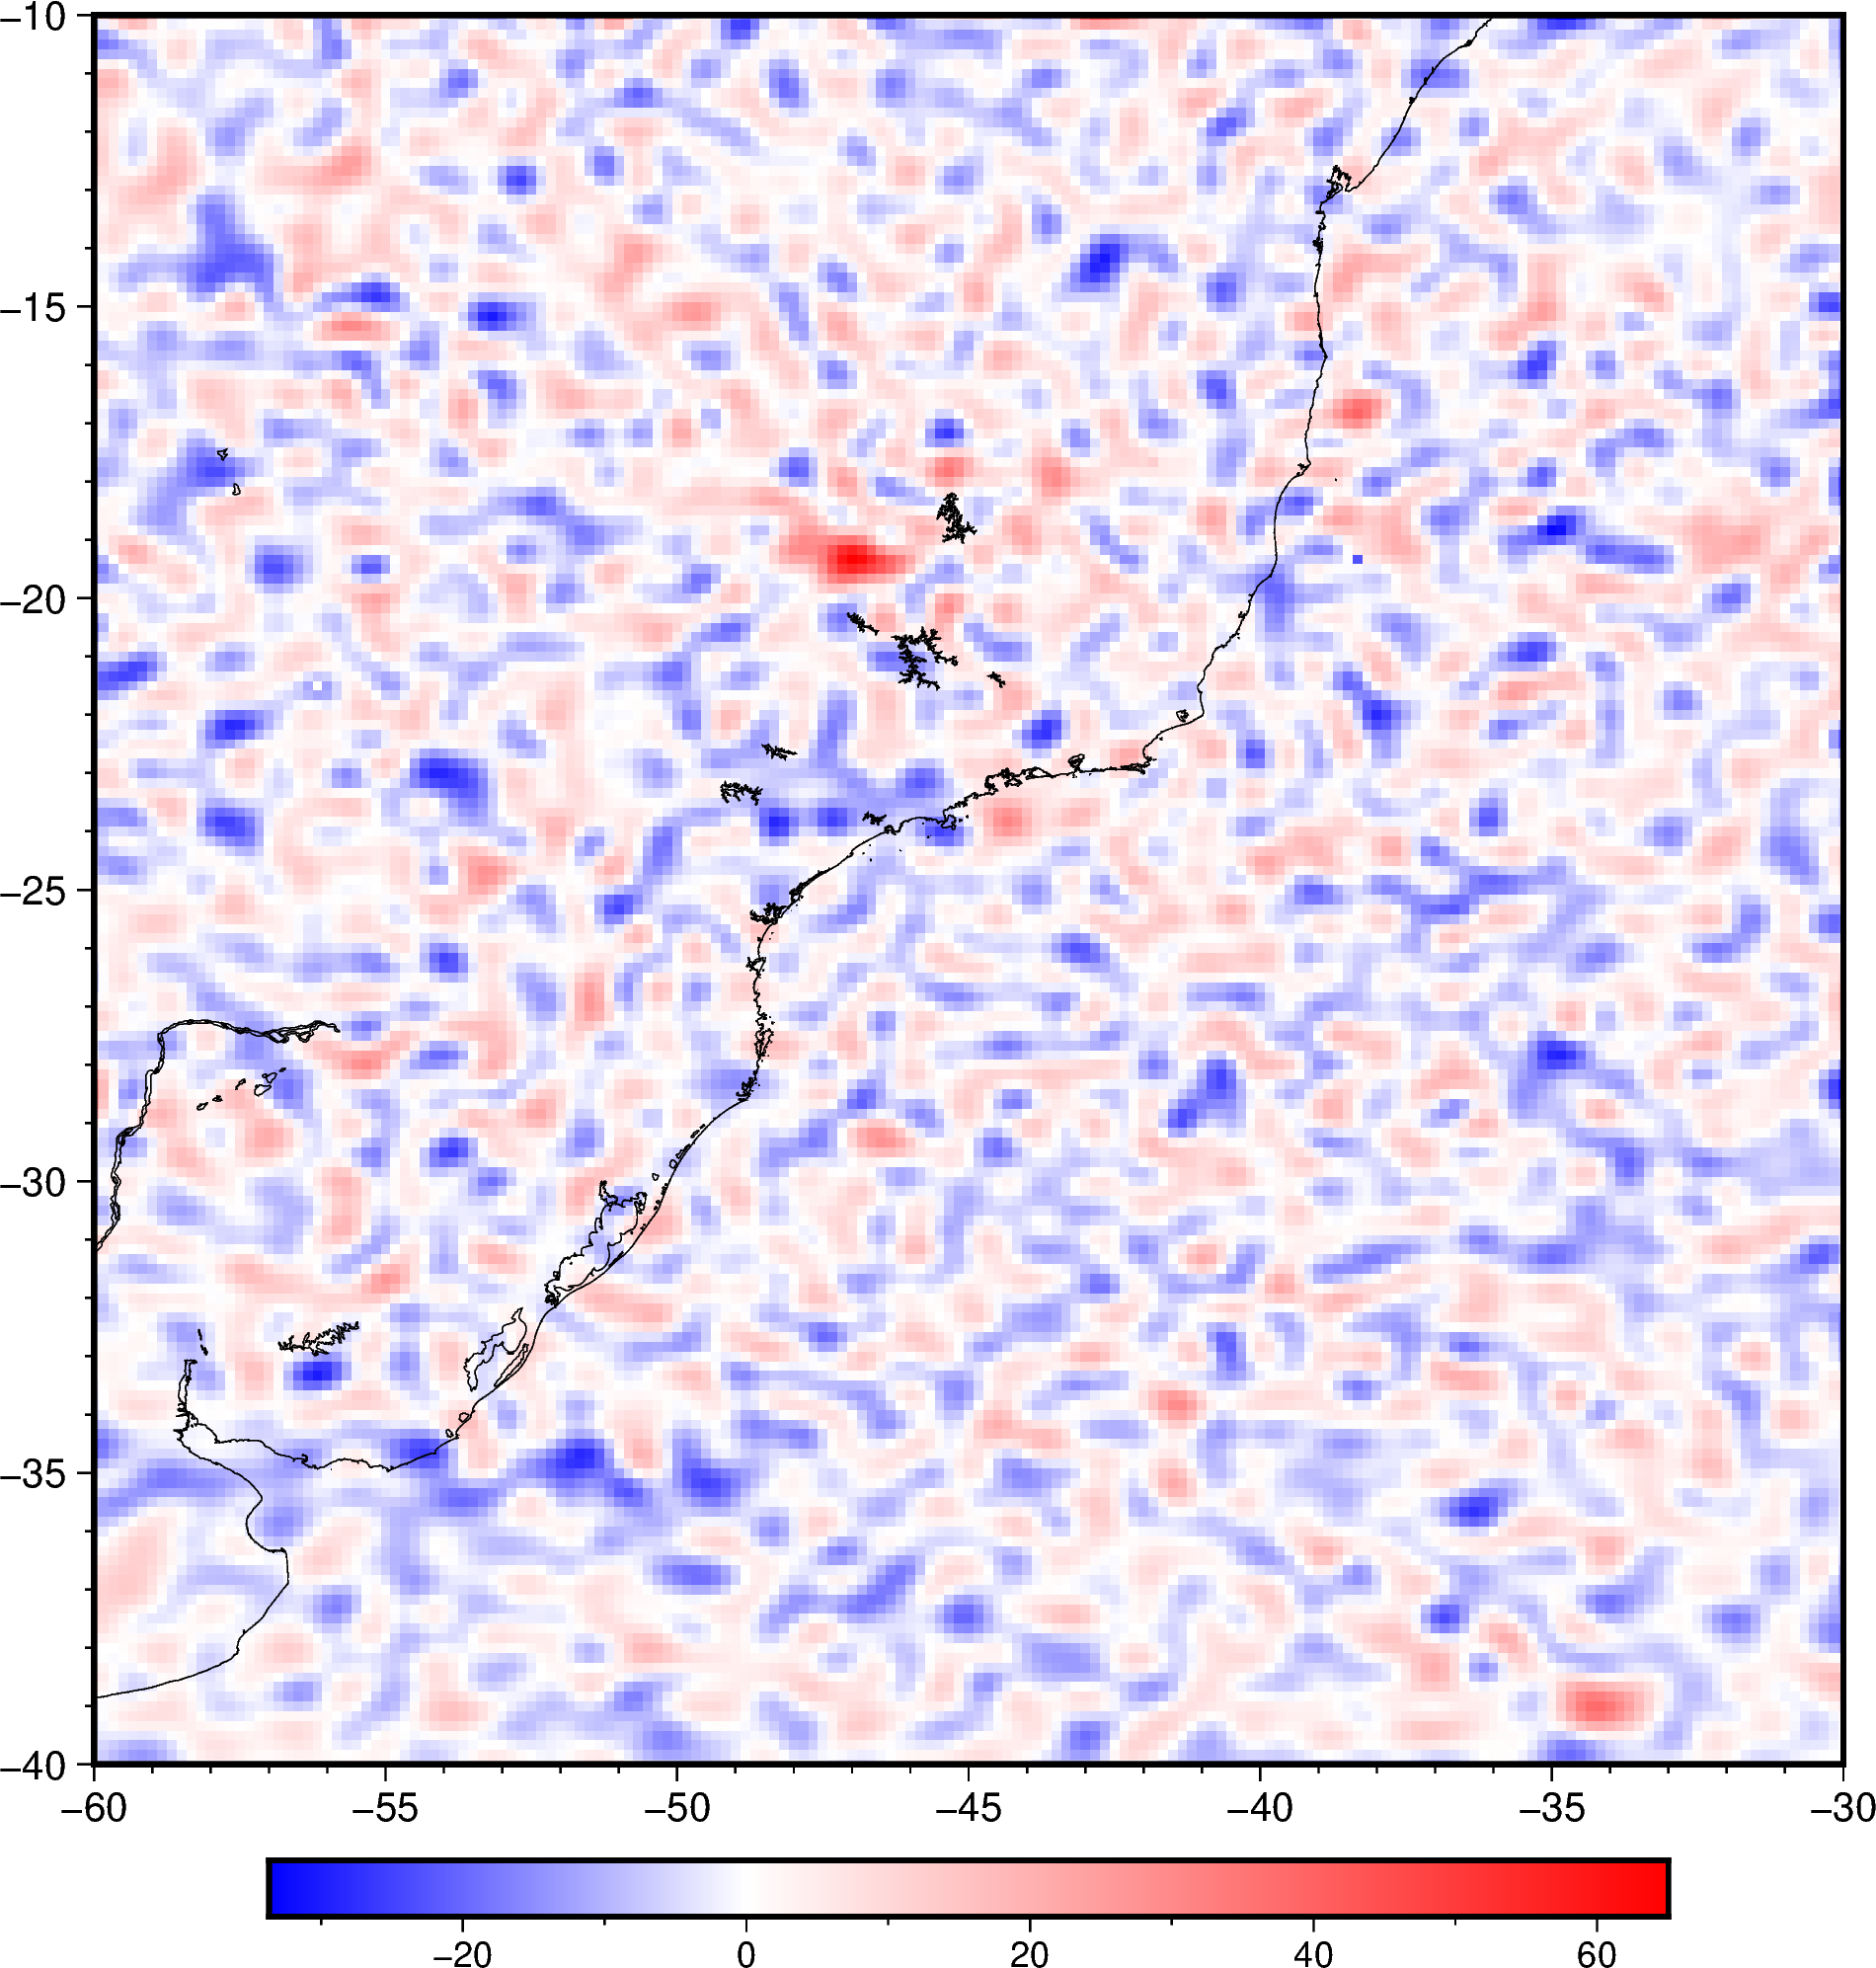

In [15]:
fig = pygmt.Figure()
fig.grdimage(total_field_anomaly - total_field_anomaly_predicted, cmap="polar+h", frame=True)
fig.colorbar()
fig.coast(shorelines=True)
fig.show()

Plot the windows.

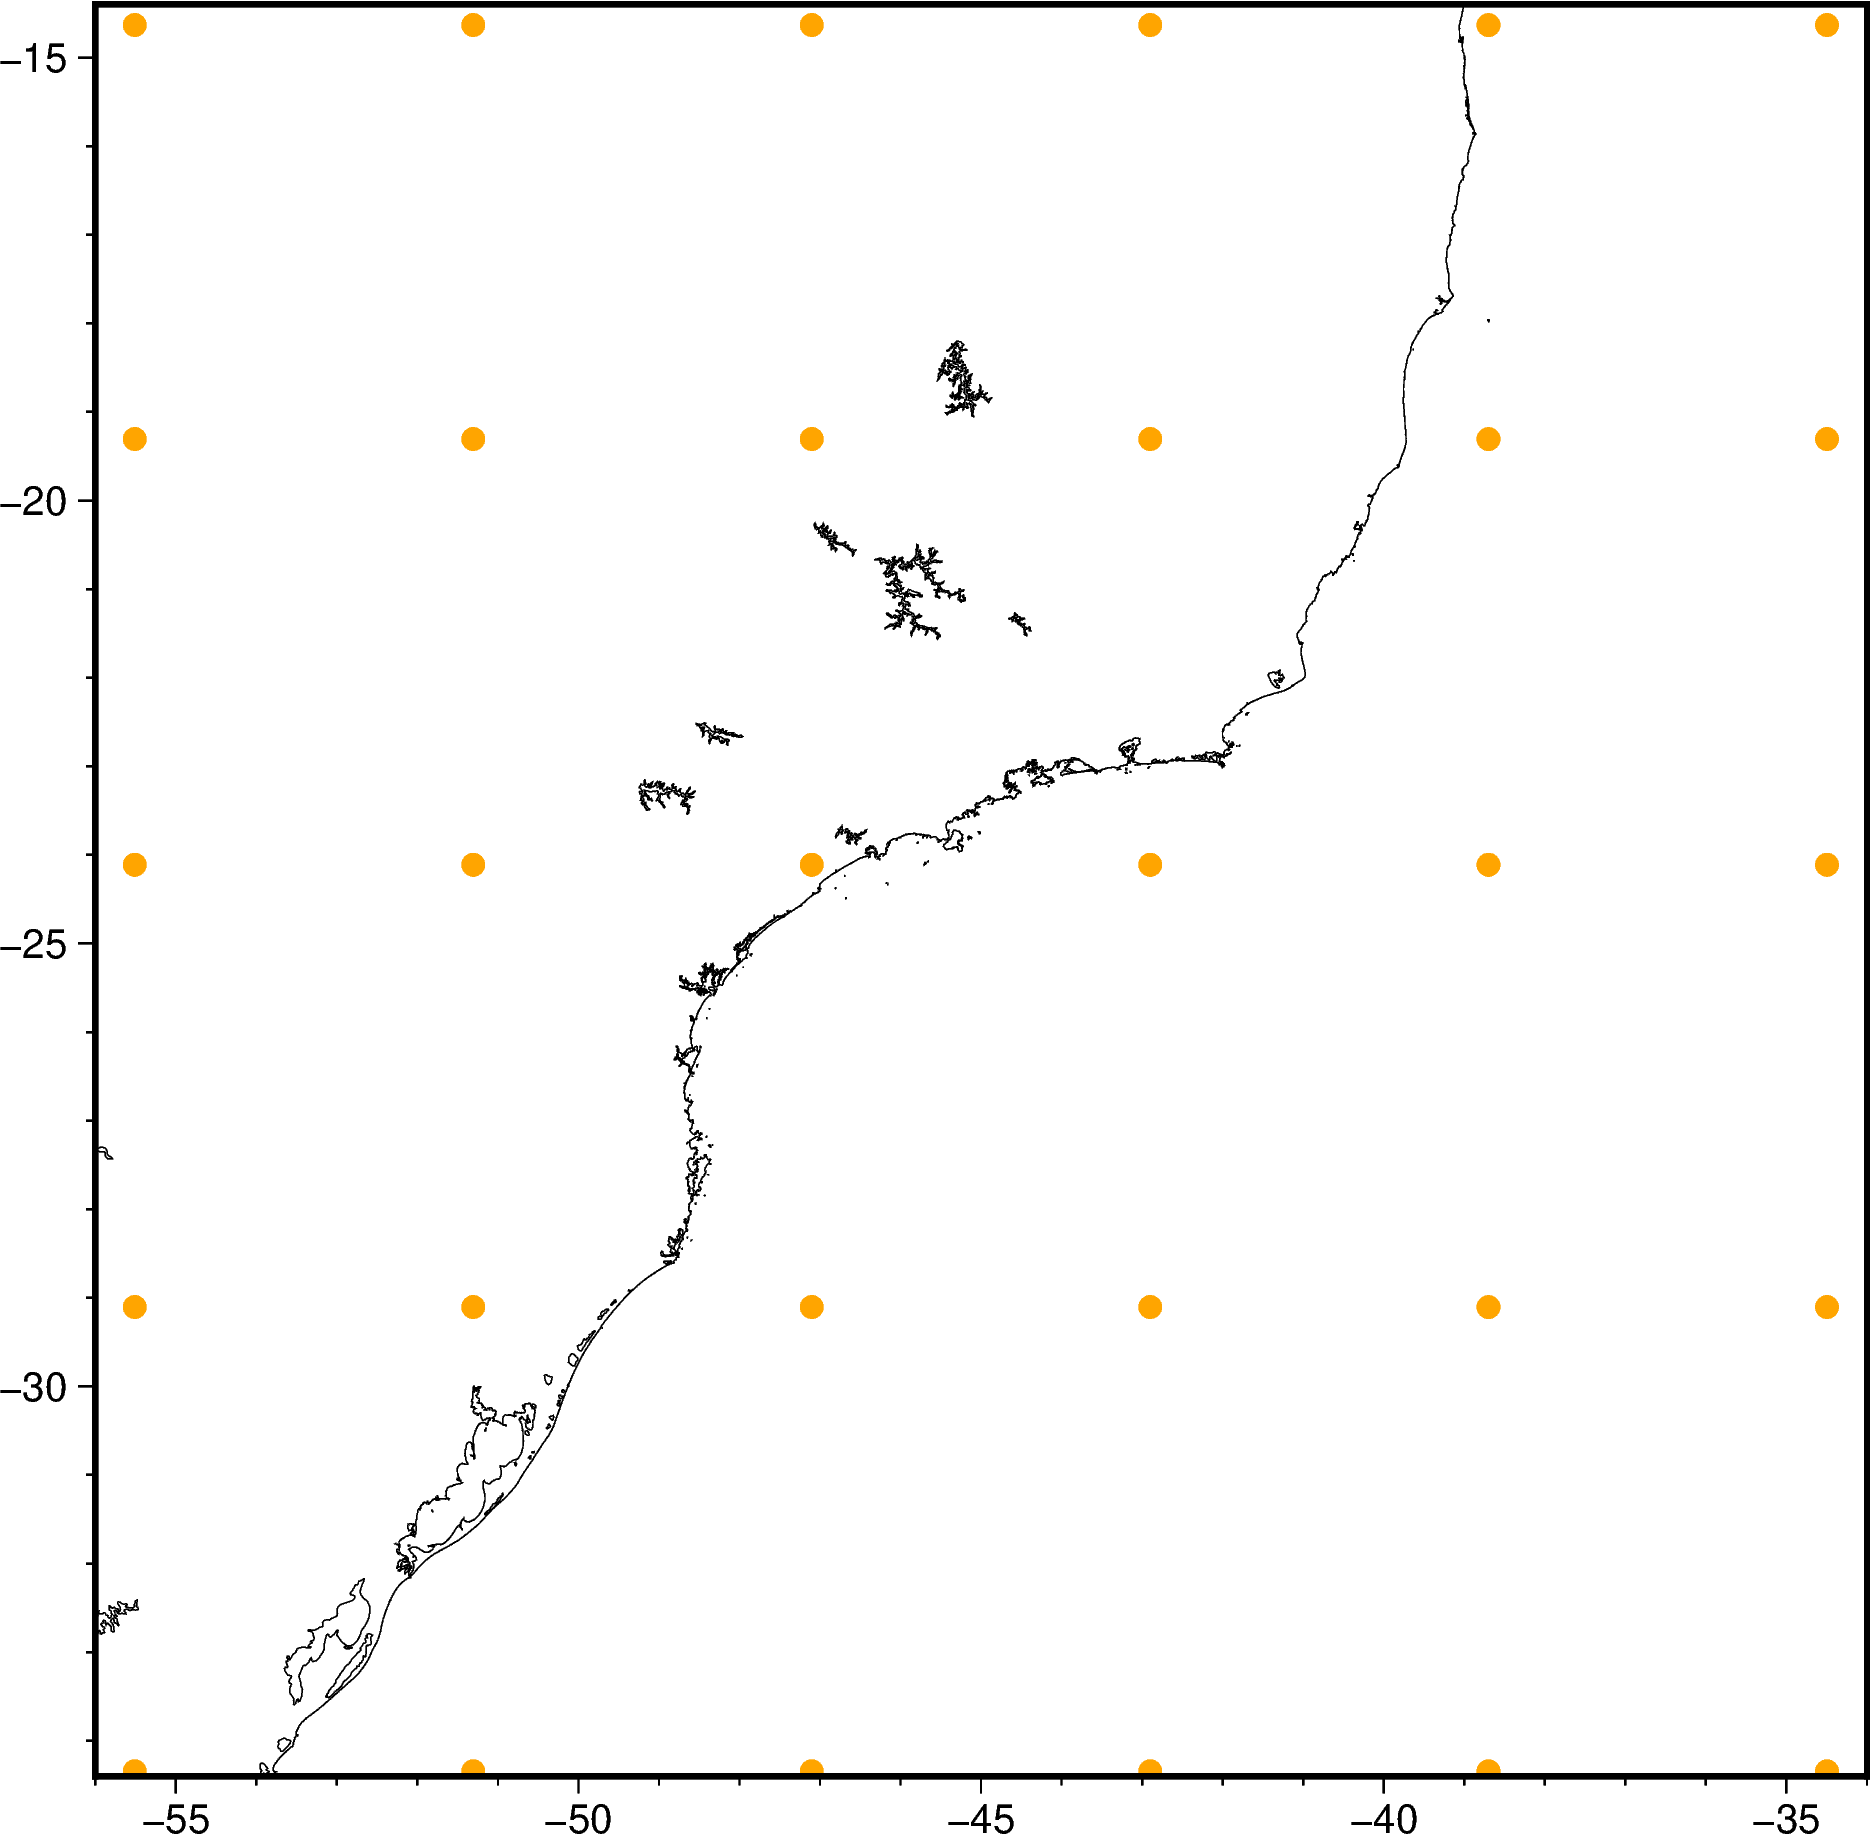

In [16]:
fig = pygmt.Figure()
fig.plot(x=eqs.window_centers_[0].ravel(), y=eqs.window_centers_[1].ravel(), fill="orange", style="c0.2c", frame=True)
fig.coast(shorelines=True)
fig.show()

## Test in the poles

In [17]:
region = (-72, -54, -74, -61)
grid_coordinates = bd.grid_coordinates(region, spacing=10 / 60, non_dimensional_coords=200)
dipole = (-66, -69, -100e3)
# Regional field
inclination, declination = -90, 0
dipole_moment = hm.magnetic_angles_to_vec(1e17, inclination, declination)
magnetic_field = sph.dipole_magnetic_geodetic(grid_coordinates, dipole, dipole_moment)
total_field_anomaly = vd.make_xarray_grid(
    grid_coordinates,
    hm.total_field_anomaly(magnetic_field, inclination, declination),
    data_names="grid",
    dims=("latitude", "longitude"),
    extra_coords_names="height",
).grid

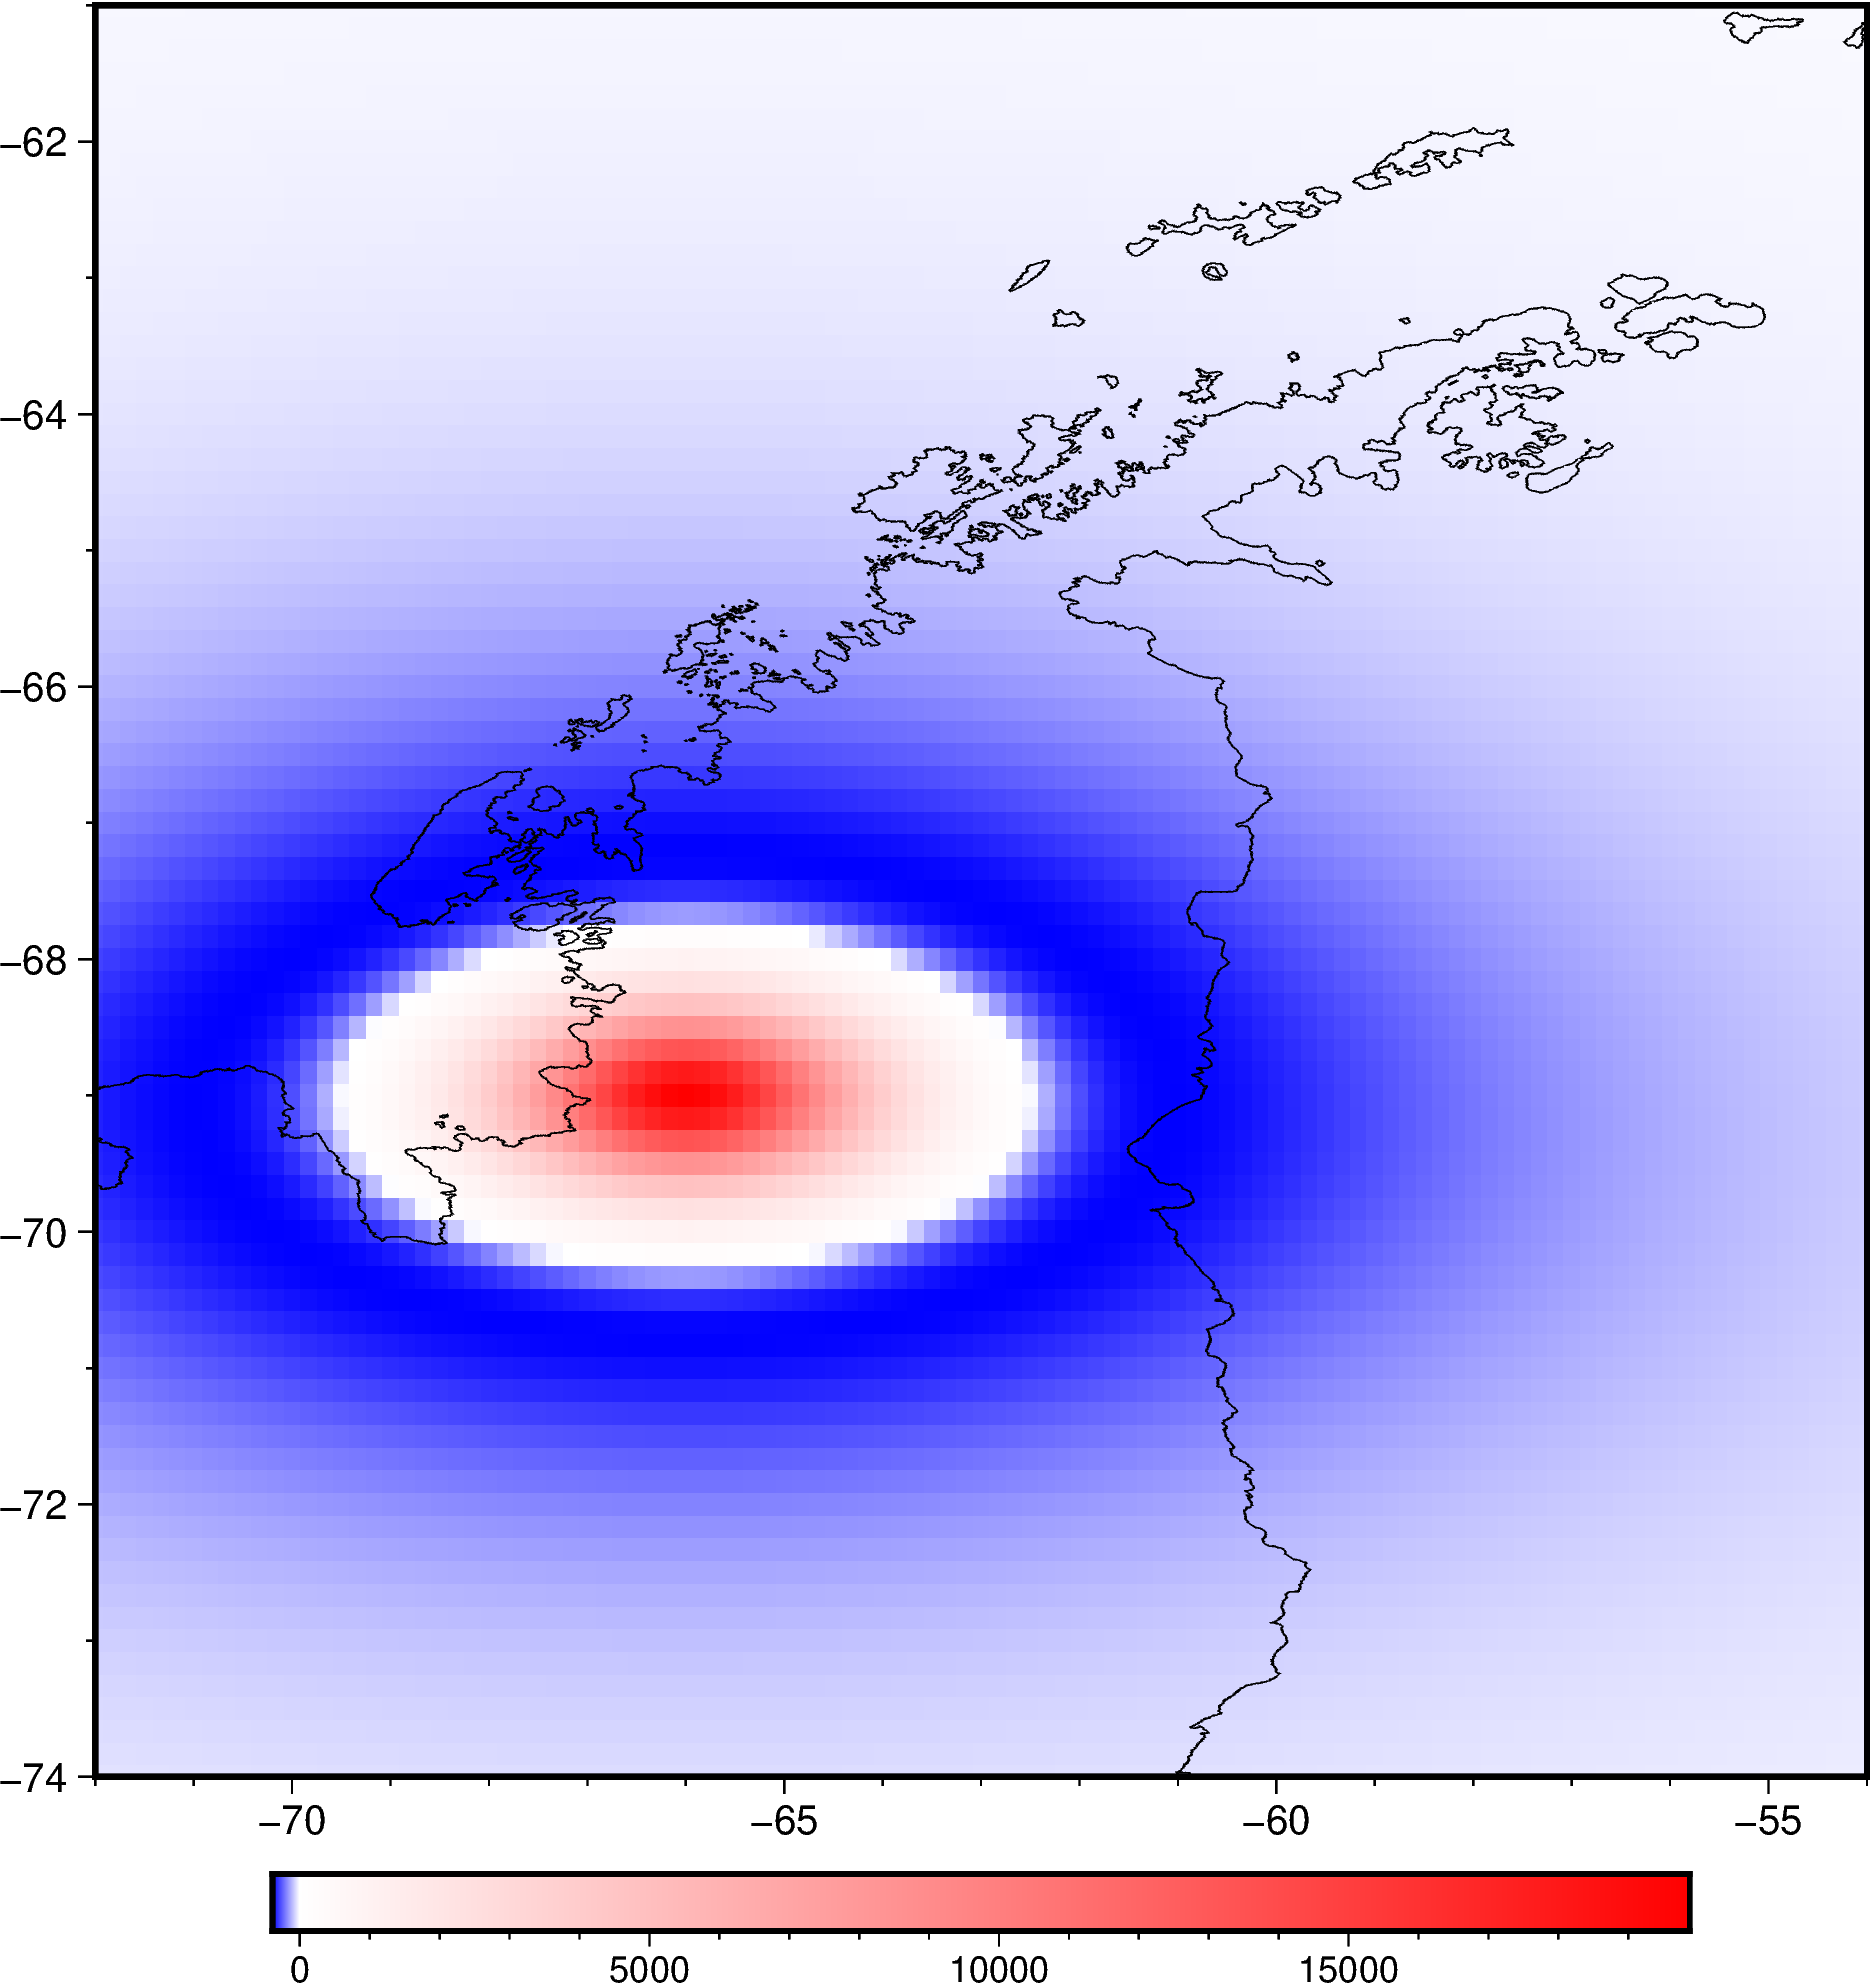

In [18]:
fig = pygmt.Figure()
fig.grdimage(total_field_anomaly, cmap="polar+h", frame=True)
fig.colorbar()
fig.coast(shorelines=True)
fig.show()

In [74]:
coordinates = bd.random_coordinates(list(region) + [150, 300], 10000)
magnetic_field_obs = sph.dipole_magnetic_geodetic(coordinates, dipole, dipole_moment)
data = hm.total_field_anomaly(magnetic_field_obs, inclination, declination)
noise_level = 0.01 * vd.maxabs(data)
data += np.random.default_rng(42).normal(0, noise_level, data.shape)
print(noise_level, "nT")

198.68800355697607 nT


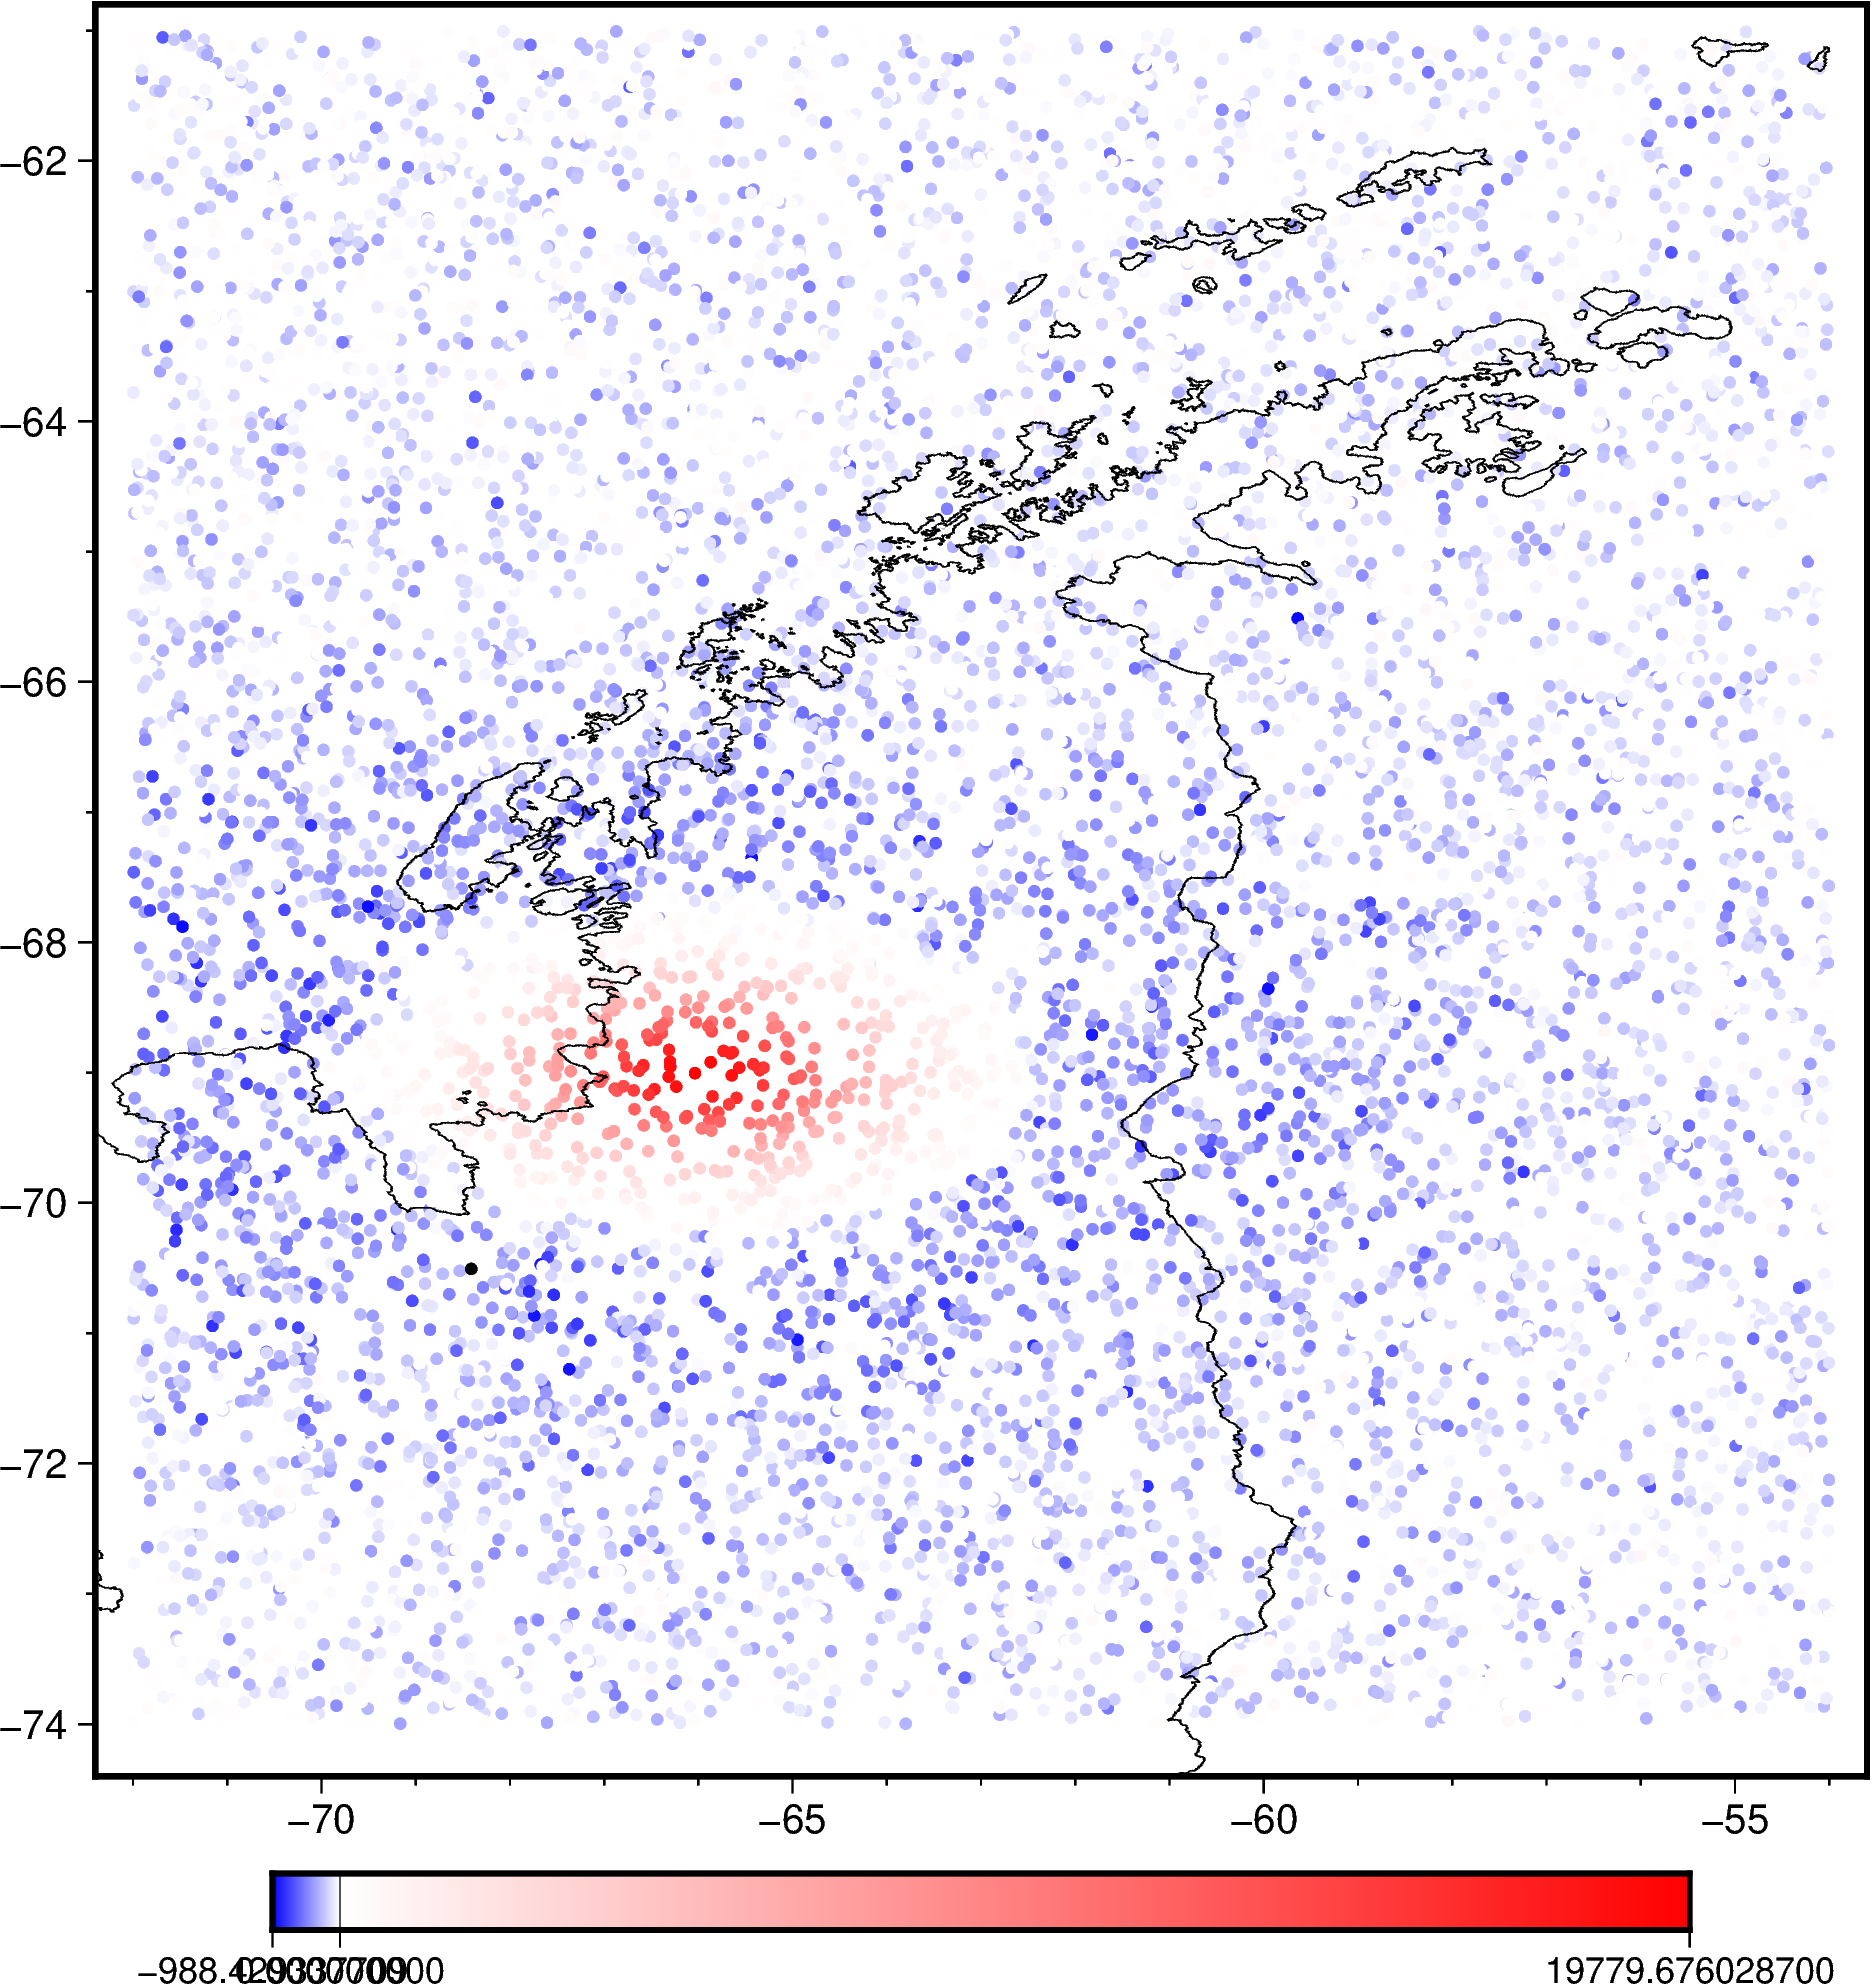

In [75]:
fig = pygmt.Figure()
pygmt.makecpt(cmap="polar+h", series=[data.min(), data.max()])
fig.plot(x=coordinates[0], y=coordinates[1], fill=data, style="c0.1c", cmap=True, frame=True)
fig.colorbar()
fig.coast(shorelines=True)
fig.show()

Try recovering the dipole field with a gradient-boosting single layer inversion in the poles.

In [82]:
%%time
proj = pyproj.Proj(
                f"+proj=ups +a={bl.WGS84.semimajor_axis} "
                f"+f={bl.WGS84.flattening}")
eqs = sph.EquivalentSourcesMagGeodGB(damping=1e1, depth=100e3)
eqs.fit(coordinates, inclination, declination, data)
print(eqs.window_size_)

Output()

554828.9898246322
CPU times: user 2min 22s, sys: 3.96 s, total: 2min 26s
Wall time: 25.7 s


Calculate and plot the residuals.

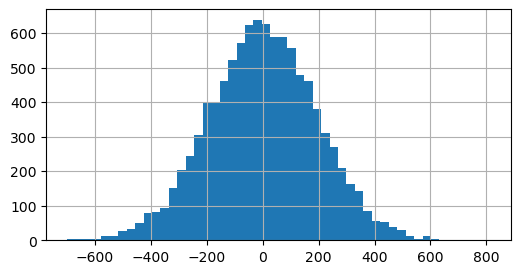

In [83]:
residuals = data - hm.total_field_anomaly(eqs.predict(coordinates), inclination, declination)
plt.figure(figsize=(6, 3))
plt.hist(residuals, bins=50)
plt.grid()
plt.show()

Predict on a grid.

In [84]:
total_field_anomaly_predicted = vd.make_xarray_grid(
    grid_coordinates,
    hm.total_field_anomaly(eqs.predict(grid_coordinates), inclination, declination),
    data_names="grid",
    dims=("latitude", "longitude"),
    extra_coords_names="height",
).grid

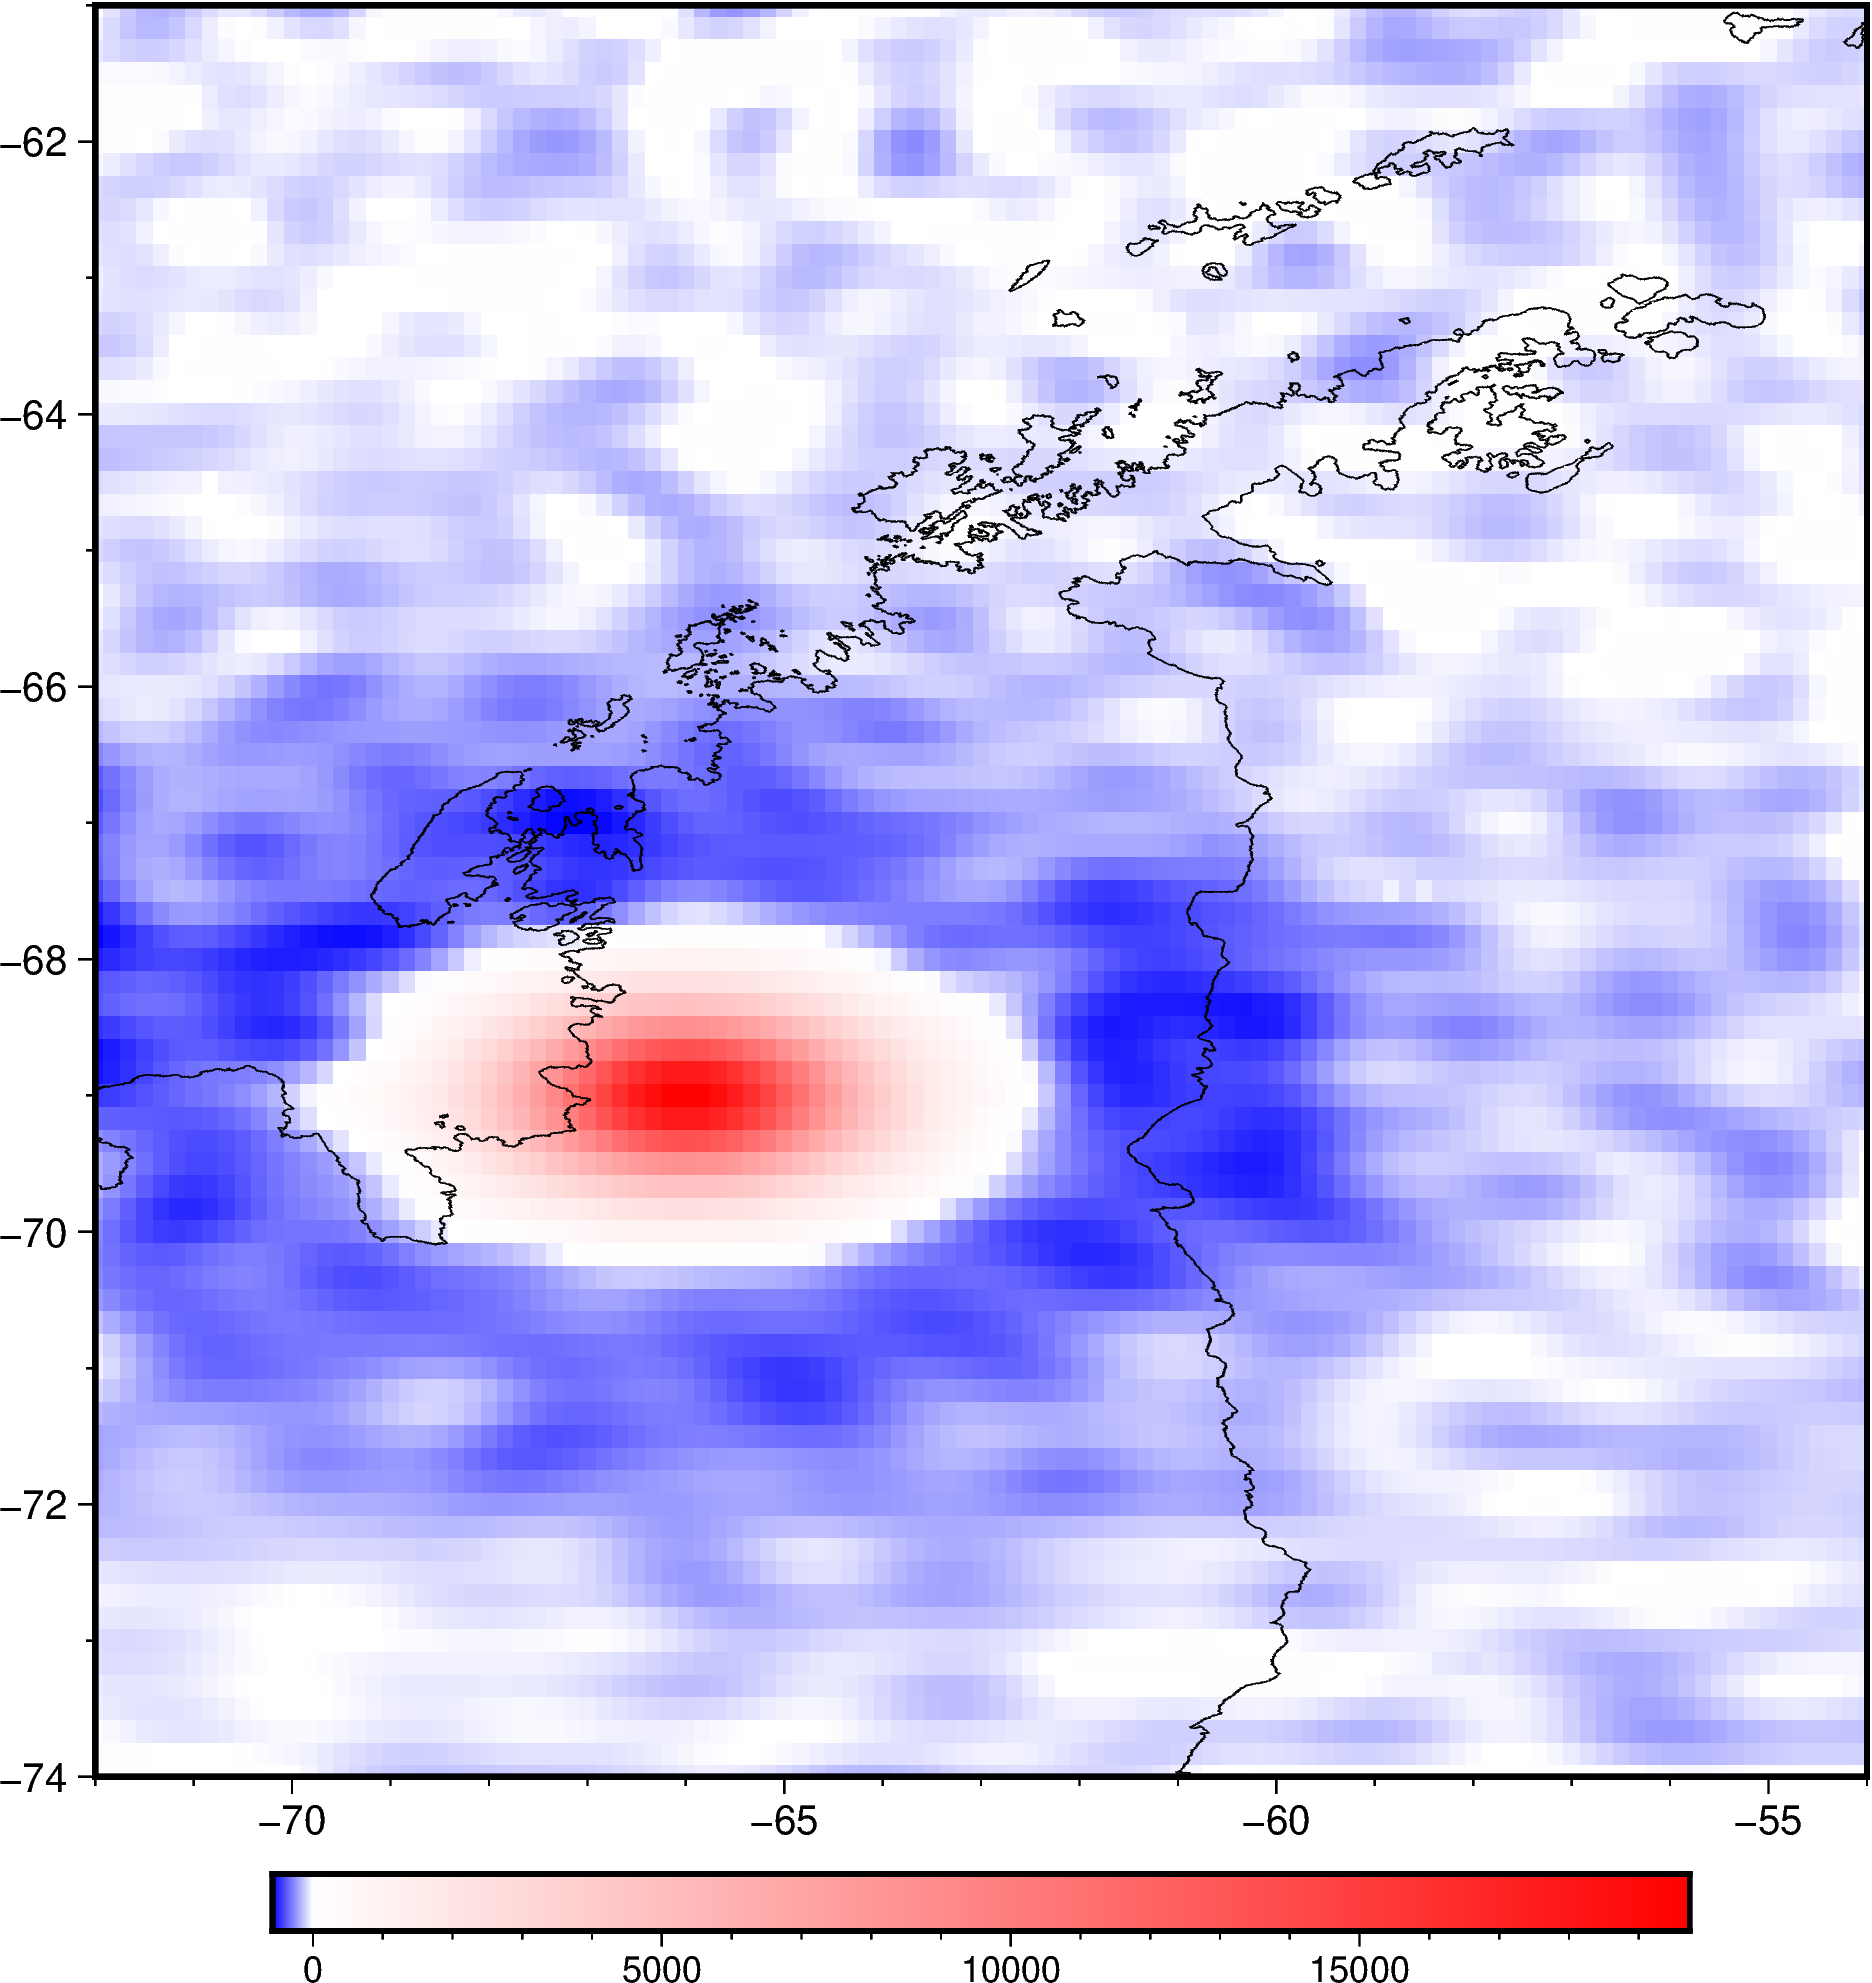

In [85]:
fig = pygmt.Figure()
fig.grdimage(total_field_anomaly_predicted, cmap="polar+h", frame=True)
fig.colorbar()
fig.coast(shorelines=True)
fig.show()

Show the difference

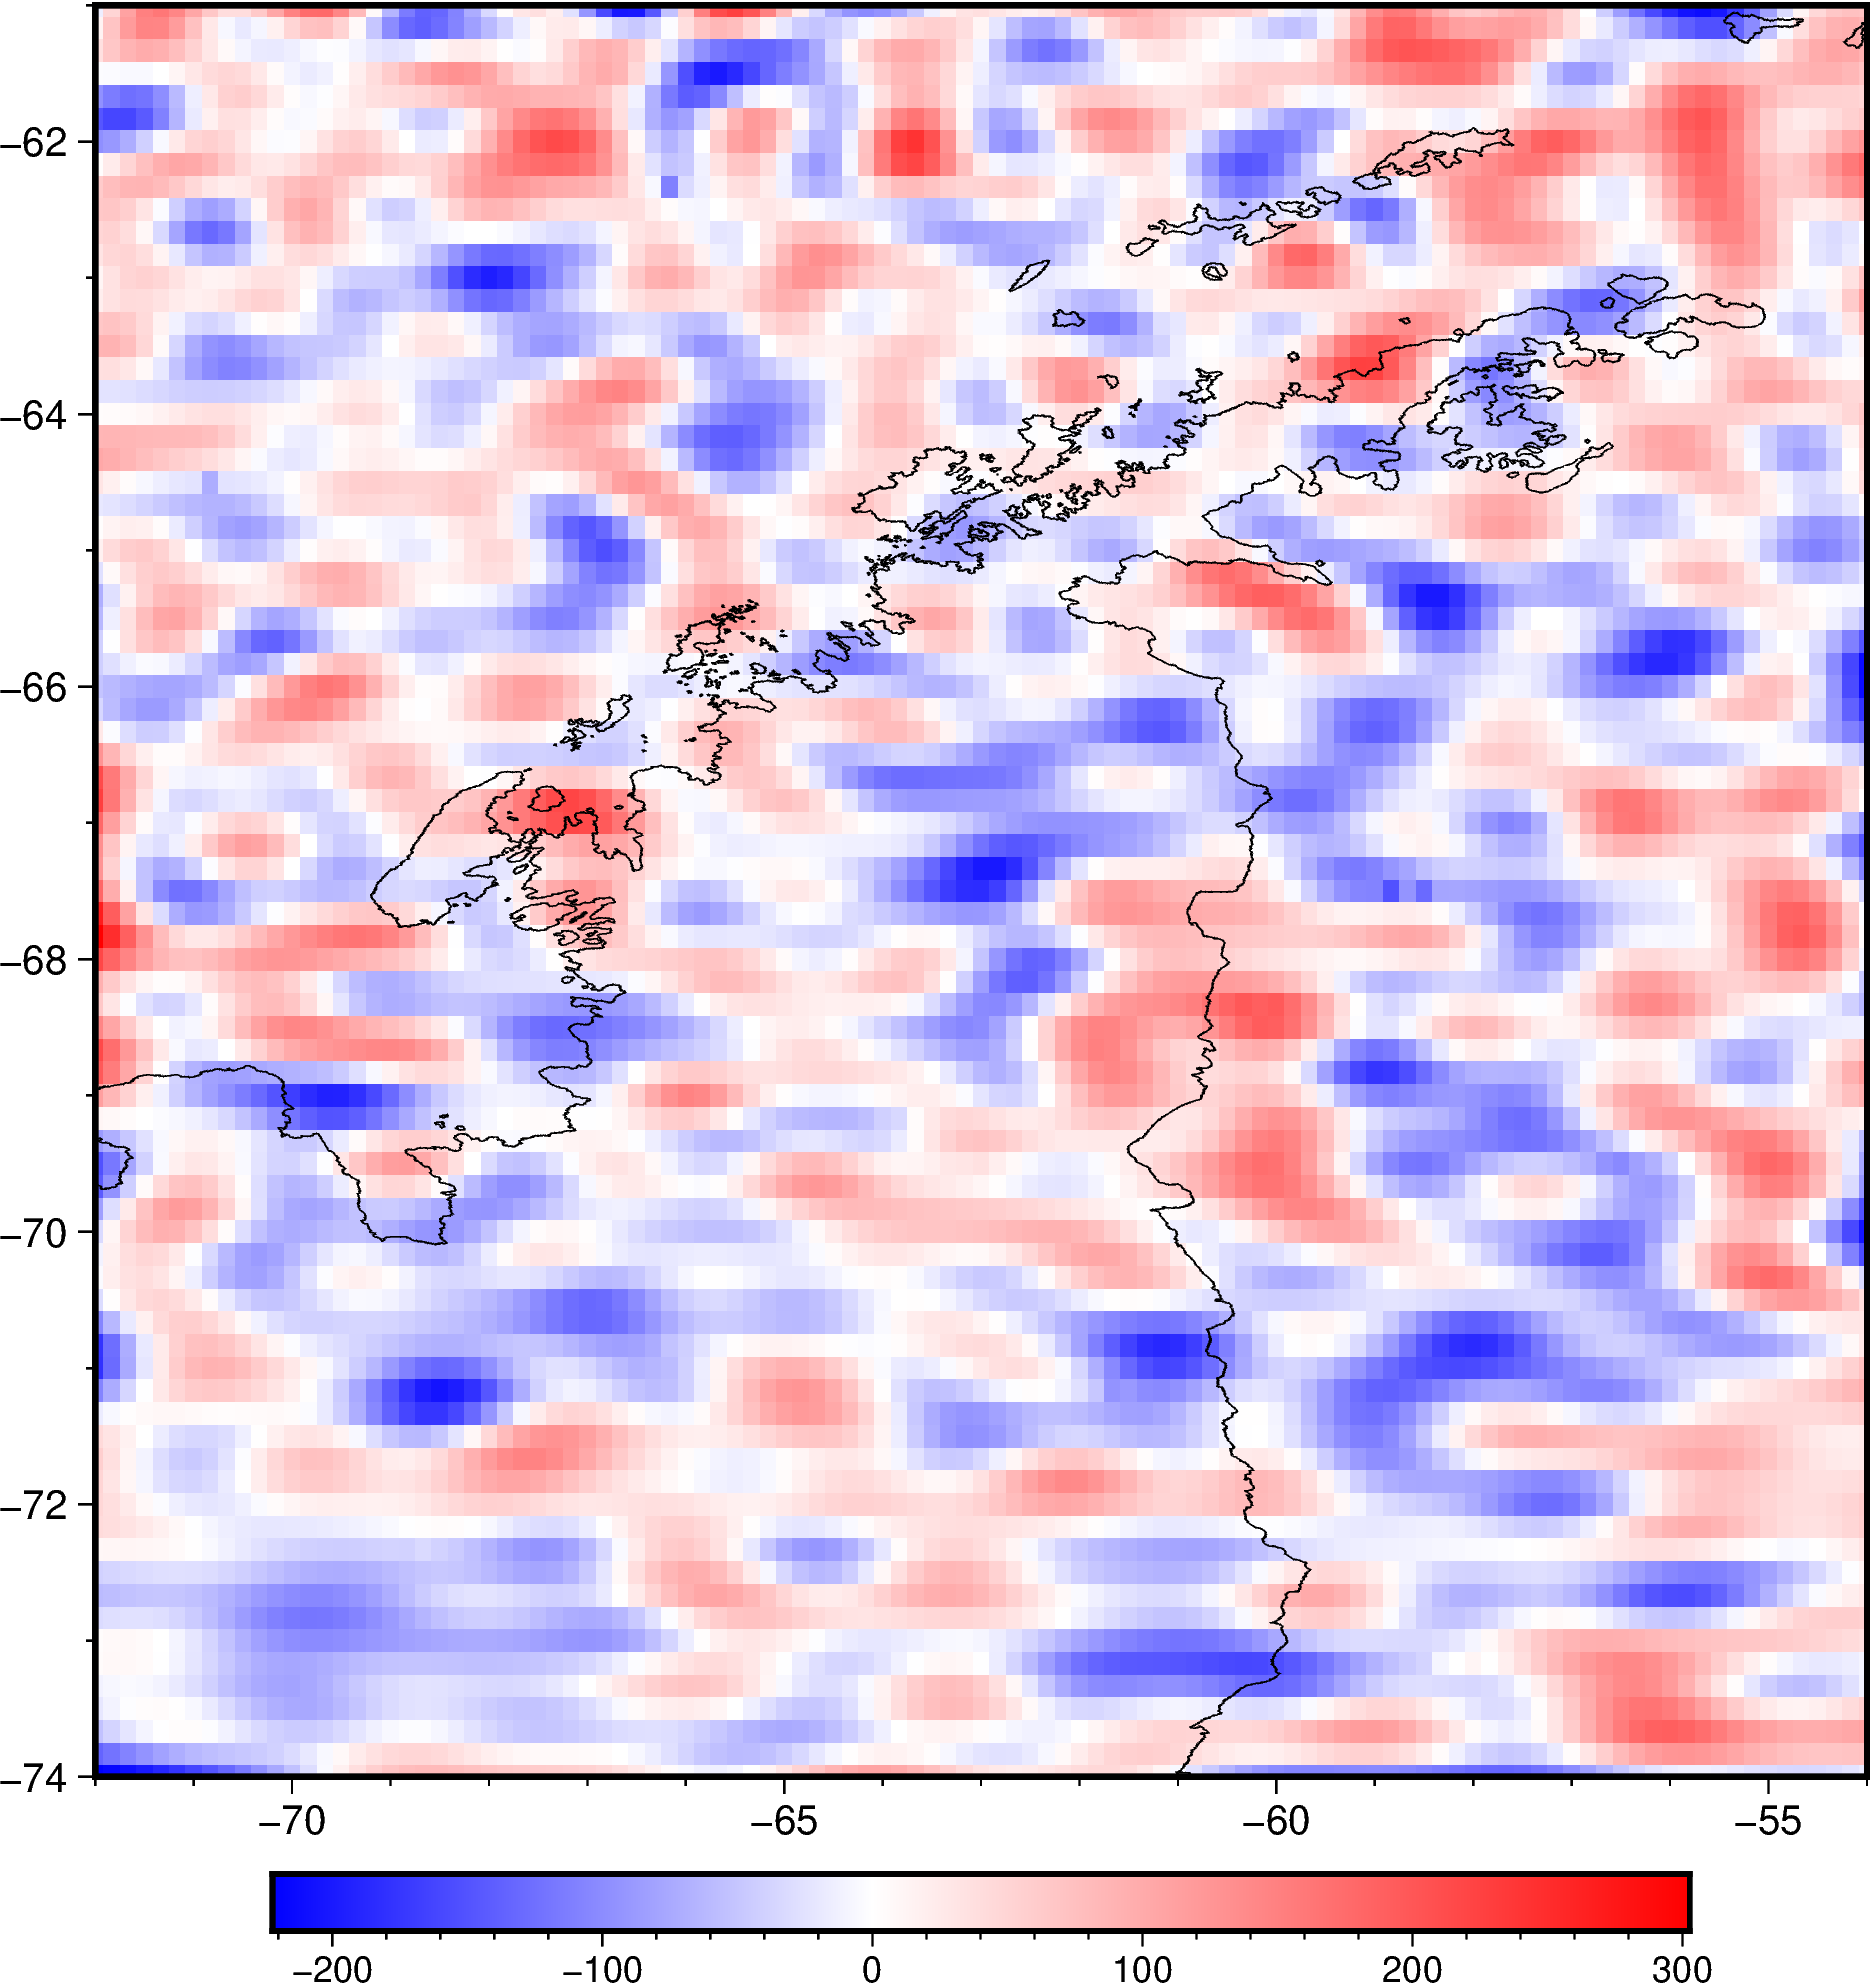

In [86]:
fig = pygmt.Figure()
fig.grdimage(total_field_anomaly - total_field_anomaly_predicted, cmap="polar+h", frame=True)
fig.colorbar()
fig.coast(shorelines=True)
fig.show()

Plot the windows.

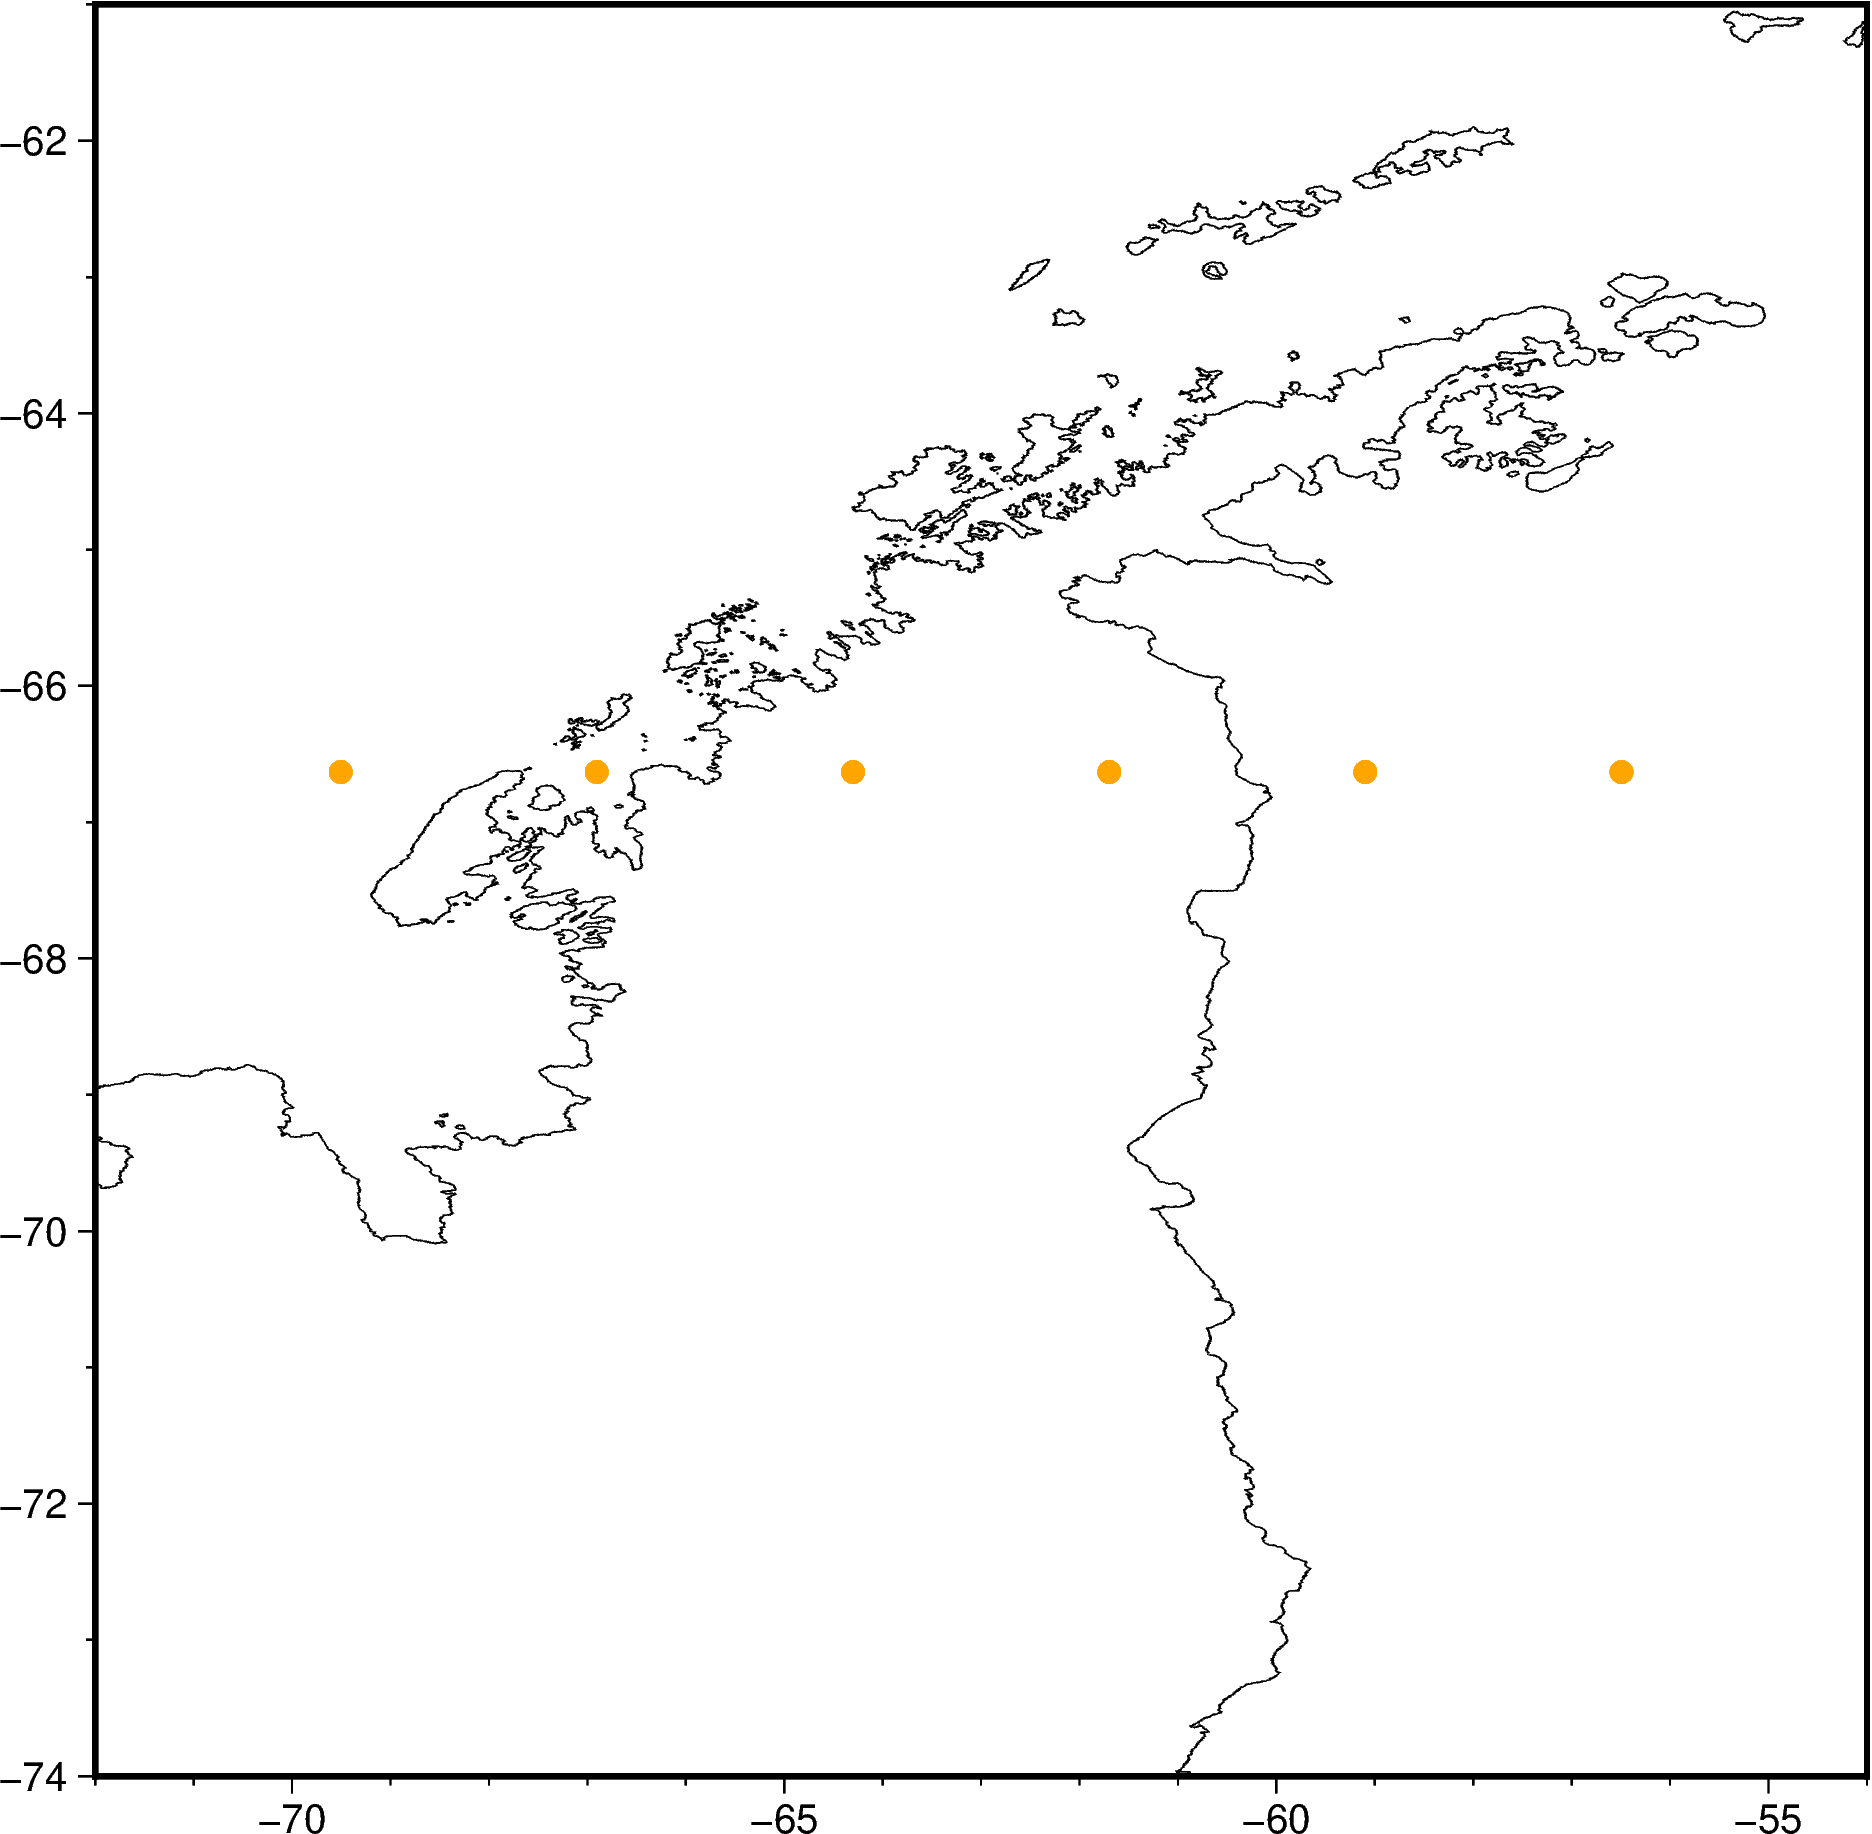

In [81]:
fig = pygmt.Figure()
fig.plot(x=eqs.window_centers_[0].ravel(), y=eqs.window_centers_[1].ravel(), fill="orange", style="c0.2c", frame=True, region=region)
fig.coast(shorelines=True)
fig.show()